# Here is a ipynb to test the combination of ratecoding SNN and forward forward algorithm


# Event base camera dataset

In [1]:
import torch
import sys
import torch.nn.functional as F
from torch.cuda import amp
from spikingjelly.activation_based import functional, surrogate, neuron
from spikingjelly.activation_based.model import parametric_lif_net
from spikingjelly.datasets.dvs128_gesture import DVS128Gesture
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import time
import os
import argparse
import datetime
import pandas as pd

In [3]:
# 在 Jupyter Notebook 中，使用 parse_args([]) 来忽略命令行参数
# 或者直接定义参数（推荐方式）
parser = argparse.ArgumentParser(description='Classify DVS Gesture')
parser.add_argument('-T', default=16, type=int, help='simulating time-steps')
parser.add_argument('-device', default='cuda:0', help='device')
parser.add_argument('-b', default=32, type=int, help='batch size')
parser.add_argument('-epochs', default=10, type=int, metavar='N',
                    help='number of total epochs to run')
parser.add_argument('-j', default=4, type=int, metavar='N',
                    help='number of data loading workers (default: 4)')
parser.add_argument('-data-dir', type=str, default='/home/public03/yhxu/spikingjelly/dataset/DVSGesture/', help='root dir of DVS Gesture dataset')
parser.add_argument('-out-dir', type=str, default='/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/DVS128/result', help='root dir for saving logs and checkpoint')
parser.add_argument('-resume', type=str, help='resume from the checkpoint path')
parser.add_argument('-amp', action='store_true', help='automatic mixed precision training')
parser.add_argument('-cupy', action='store_true', help='use cupy backend')
parser.add_argument('-opt', type=str, default='adam', help='use which optimizer. SDG or Adam')
parser.add_argument('-momentum', default=0.9, type=float, help='momentum for SGD')
parser.add_argument('-lr', default=1e-3, type=float, help='learning rate')
parser.add_argument('-channels', default=128, type=int, help='channels of CSNN')

# 关键修复：使用 parse_args([]) 而不是 parse_args()
# 这样会忽略 sys.argv，只使用默认值
args = parser.parse_args([])
print(args)

Namespace(T=16, device='cuda:0', b=32, epochs=10, j=4, data_dir='/home/public03/yhxu/spikingjelly/dataset/DVSGesture/', out_dir='/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/DVS128/result', resume=None, amp=False, cupy=False, opt='adam', momentum=0.9, lr=0.001, channels=128)


In [4]:
"""
Fixed resize_collate_fn - handles numpy arrays from dataset
"""
import torch
import torch.nn.functional as F
import numpy as np

def resize_collate_fn(batch, target_size=(20, 20)):
    """
    Resize data from 128x128 to target_size
    Handles both numpy arrays and tensors from DVS128Gesture dataset
    """
    frames, labels = zip(*batch)
    
    # Convert frames to tensors if they are numpy arrays
    # DVS128Gesture may return numpy arrays, so we need to handle both cases
    frames_tensor = []
    for frame in frames:
        if isinstance(frame, np.ndarray):
            # Convert numpy array to tensor
            frame_tensor = torch.from_numpy(frame).float()
        elif isinstance(frame, torch.Tensor):
            # Already a tensor, ensure it's float
            frame_tensor = frame.float()
        else:
            raise TypeError(f"Unexpected frame type: {type(frame)}")
        frames_tensor.append(frame_tensor)
    
    # Stack frames: [N, T, C, H, W], e.g., [N, T, 2, 128, 128]
    frames = torch.stack(frames_tensor)
    
    # Convert labels to tensor
    if isinstance(labels[0], (np.ndarray, np.integer, int)):
        labels = torch.tensor(labels, dtype=torch.long)
    else:
        labels = torch.tensor(labels)
    
    # Resize: [N, T, C, H, W] -> [N*T*C, H, W] -> resize -> [N, T, C, H_new, W_new]
    N, T, C, H, W = frames.shape
    frames_reshaped = frames.view(N * T * C, H, W).unsqueeze(1)  # [N*T*C, 1, H, W]
    
    # Use F.interpolate for resize (bilinear interpolation)
    frames_resized = F.interpolate(
        frames_reshaped,
        size=target_size,
        mode='bilinear',
        align_corners=False
    ).squeeze(1)  # [N*T*C, H_new, W_new]
    
    # Reshape back to [N, T, C, H_new, W_new]
    frames_resized = frames_resized.view(N, T, C, target_size[0], target_size[1])
    
    return frames_resized, labels

In [5]:
# 设置目标尺寸
TARGET_SIZE = (20, 20)
INPUT_SIZE = 2 * TARGET_SIZE[0] * TARGET_SIZE[1]  # 800 = 2 * 20 * 20

print(f"Original input size: 32768 (2 * 128 * 128)")
print(f"New input size: {INPUT_SIZE} (2 * {TARGET_SIZE[0]} * {TARGET_SIZE[1]})")

train_set = DVS128Gesture(root=args.data_dir, train=True, data_type='frame', frames_number=args.T, split_by='number')
test_set = DVS128Gesture(root=args.data_dir, train=False, data_type='frame', frames_number=args.T, split_by='number')

train_data_loader = torch.utils.data.DataLoader(
    dataset=train_set,
    batch_size=args.b,
    shuffle=True,
    drop_last=True,
    num_workers=args.j,
    pin_memory=True,
    collate_fn=lambda batch: resize_collate_fn(batch, target_size=TARGET_SIZE)  # ← 添加这一行
)

test_data_loader = torch.utils.data.DataLoader(
    dataset=test_set,
    batch_size=args.b,
    shuffle=True,
    drop_last=False,
    num_workers=args.j,
    pin_memory=True,
    collate_fn=lambda batch: resize_collate_fn(batch, target_size=TARGET_SIZE)  # ← 添加这一行
)

Original input size: 32768 (2 * 128 * 128)
New input size: 800 (2 * 20 * 20)
The directory [/home/public03/yhxu/spikingjelly/dataset/DVSGesture/frames_number_16_split_by_number] already exists.
The directory [/home/public03/yhxu/spikingjelly/dataset/DVSGesture/frames_number_16_split_by_number] already exists.


In [15]:
# ============================================================================
# 改进的 Forward-Forward 辅助函数（按照原始FF算法）
# ============================================================================

def create_positive_sample(frames, labels, num_classes=11):
    """
    创建正样本：在label对应的位置添加标记
    
    原始FF算法：
    - 在输入中添加额外的pixel/channel
    - 正样本：在正确label对应的位置设置为1
    
    Args:
        frames: 原始frames，应该是 [T, N, C, H, W] 格式（训练代码已经做了transpose）
        labels: 标签 [N]
        num_classes: 类别数量
    
    Returns:
        positive_frames: 正样本frames，在flatten后添加了label信息 [T, N, C*H*W + num_classes]
    """
    # 确保frames是 [T, N, C, H, W] 格式
    # 训练代码中已经做了 frame.transpose(0, 1)，所以输入应该是 [T, N, C, H, W]
    # 但为了安全，检查并转换
    if frames.dim() == 5:
        # 更安全的判断：检查第二个维度（索引1）是否等于labels的数量
        # 如果是，说明格式是 [T, N, ...]（正确）
        # 如果不是，但第一个维度（索引0）等于labels数量，说明是 [N, T, ...]（需要转置）
        if frames.shape[1] == labels.shape[0]:
            # 第二个维度匹配labels，说明是 [T, N, C, H, W] 格式，正确
            pass
        elif frames.shape[0] == labels.shape[0]:
            # 第一个维度匹配labels，说明是 [N, T, C, H, W] 格式，需要转置
            frames = frames.transpose(0, 1)  # [N, T, C, H, W] -> [T, N, C, H, W]
        else:
            # 都不匹配，可能有问题，但假设格式正确
            pass
    
    T, N, C, H, W = frames.shape
    
    # 验证N是否匹配labels
    assert N == labels.shape[0], f"Batch size mismatch: frames shape={frames.shape}, frames N={N}, labels={labels.shape[0]}"
    
    # Flatten frames: [T, N, C, H, W] -> [T, N, C*H*W]
    frames_flat = frames.contiguous().view(T, N, C * H * W)
    
    # 创建label one-hot编码 [N, num_classes]
    label_onehot = F.one_hot(labels, num_classes).float()  # [N, num_classes]
    
    # 将label信息添加到每一帧
    # 扩展label_onehot到 [T, N, num_classes]
    # 先unsqueeze增加时间维度，然后repeat扩展到T
    label_expanded = label_onehot.unsqueeze(0)  # [1, N, num_classes]
    label_expanded = label_expanded.repeat(T, 1, 1)  # [T, N, num_classes]
    
    # 验证维度匹配
    assert frames_flat.shape[0] == label_expanded.shape[0], f"Time dimension mismatch: frames T={frames_flat.shape[0]}, labels T={label_expanded.shape[0]}"
    assert frames_flat.shape[1] == label_expanded.shape[1], f"Batch dimension mismatch: frames N={frames_flat.shape[1]}, labels N={label_expanded.shape[1]}"
    
    # Concatenate: [T, N, C*H*W] + [T, N, num_classes] -> [T, N, C*H*W + num_classes]
    positive_frames = torch.cat([frames_flat, label_expanded], dim=2)  # [T, N, C*H*W + num_classes]
    
    return positive_frames


def create_negative_sample(frames, labels, num_classes=11, method='random_wrong_label'):
    """
    创建负样本：在错误label对应的位置添加标记
    
    原始FF算法：
    - 负样本：在除了正确label之外的随机位置设置为1
    
    Args:
        frames: 原始frames，应该是 [T, N, C, H, W] 格式（训练代码已经做了transpose）
        labels: 标签 [N]
        num_classes: 类别数量
        method: 负样本生成方法
            - 'random_wrong_label': 随机选择一个错误的label
            - 'shuffle_labels': 随机shuffle labels
    
    Returns:
        negative_frames: 负样本frames，在flatten后添加了错误label信息 [T, N, C*H*W + num_classes]
    """
    # 确保frames是 [T, N, C, H, W] 格式
    # 训练代码中已经做了 frame.transpose(0, 1)，所以输入应该是 [T, N, C, H, W]
    # 但为了安全，检查并转换
    if frames.dim() == 5:
        # 更安全的判断：检查第二个维度（索引1）是否等于labels的数量
        # 如果是，说明格式是 [T, N, ...]（正确）
        # 如果不是，但第一个维度（索引0）等于labels数量，说明是 [N, T, ...]（需要转置）
        if frames.shape[1] == labels.shape[0]:
            # 第二个维度匹配labels，说明是 [T, N, C, H, W] 格式，正确
            pass
        elif frames.shape[0] == labels.shape[0]:
            # 第一个维度匹配labels，说明是 [N, T, C, H, W] 格式，需要转置
            frames = frames.transpose(0, 1)  # [N, T, C, H, W] -> [T, N, C, H, W]
        else:
            # 都不匹配，可能有问题，但假设格式正确
            pass
    
    T, N, C, H, W = frames.shape
    
    # 验证N是否匹配labels
    assert N == labels.shape[0], f"Batch size mismatch: frames shape={frames.shape}, frames N={N}, labels={labels.shape[0]}"
    
    # Flatten frames: [T, N, C, H, W] -> [T, N, C*H*W]
    frames_flat = frames.contiguous().view(T, N, C * H * W)
    
    # 生成错误的labels
    if method == 'random_wrong_label':
        # 为每个样本随机选择一个错误的label
        wrong_labels = []
        for label in labels:
            # 从除了正确label之外的类别中随机选择
            wrong_label = torch.randint(0, num_classes, (1,), device=labels.device).item()
            while wrong_label == label.item():
                wrong_label = torch.randint(0, num_classes, (1,), device=labels.device).item()
            wrong_labels.append(wrong_label)
        wrong_labels = torch.tensor(wrong_labels, device=labels.device)
    
    elif method == 'shuffle_labels':
        # 随机shuffle labels
        wrong_labels = labels[torch.randperm(N, device=labels.device)]
        # 确保至少有一些是错的（但可能全部都是错的，这也是可以的）
    
    else:
        raise ValueError(f"Unknown negative sample method: {method}")
    
    # 创建错误label的one-hot编码 [N, num_classes]
    wrong_label_onehot = F.one_hot(wrong_labels, num_classes).float()  # [N, num_classes]
    
    # 将错误label信息添加到每一帧
    # 扩展label_onehot到 [T, N, num_classes]
    # 先unsqueeze增加时间维度，然后repeat扩展到T
    label_expanded = wrong_label_onehot.unsqueeze(0)  # [1, N, num_classes]
    label_expanded = label_expanded.repeat(T, 1, 1)  # [T, N, num_classes]
    
    # 验证维度匹配
    assert frames_flat.shape[0] == label_expanded.shape[0], f"Time dimension mismatch: frames T={frames_flat.shape[0]}, labels T={label_expanded.shape[0]}"
    assert frames_flat.shape[1] == label_expanded.shape[1], f"Batch dimension mismatch: frames N={frames_flat.shape[1]}, labels N={label_expanded.shape[1]}"
    
    # Concatenate: [T, N, C*H*W] + [T, N, num_classes] -> [T, N, C*H*W + num_classes]
    negative_frames = torch.cat([frames_flat, label_expanded], dim=2)  # [T, N, C*H*W + num_classes]
    
    return negative_frames


def normalize_layer_output(output, method='l2_norm', eps=1e-8, scale_factor=1.0):
    """
    对层输出进行归一化（标准Forward-Forward算法要求）
    
    Args:
        output: 层输出 [T, N, features] 或其他形状
        method: 归一化方法
            - 'l2_norm': L2归一化
            - 'layer_norm': Layer Normalization
            - 'mean_std': 均值和标准差归一化
            - 'threshold_norm': 阈值归一化（适合sparse spike）
        eps: 防止除零的小值
        scale_factor: 缩放因子（用于调整归一化后的数值范围）
    
    Returns:
        normalized_output: 归一化后的输出
    """
    if method == 'l2_norm':
        # L2归一化：对每个样本的feature维度进行L2归一化
        # 对于sparse spike，L2范数可能很小，导致归一化后数值过小
        if output.dim() == 3:  # [T, N, features]
            # 对每个时间步的每个样本进行L2归一化
            # 先对时间维度求和，然后归一化
            output_sum = output.sum(dim=0)  # [N, features]
            norm = output_sum.norm(dim=1, keepdim=True) + eps  # [N, 1]
            # 将归一化应用到所有时间步
            normalized = output / (norm.unsqueeze(0) + eps) * scale_factor  # [T, N, features]
        elif output.dim() == 2:  # [N, features]
            norm = output.norm(dim=1, keepdim=True) + eps
            normalized = output / norm * scale_factor
        else:
            # 对于其他维度，对最后一个维度归一化
            norm = output.norm(dim=-1, keepdim=True) + eps
            normalized = output / norm * scale_factor
        return normalized
    
    elif method == 'mean_std':
        # 均值和标准差归一化
        if output.dim() == 3:  # [T, N, features]
            # 对时间维度求和后归一化
            output_sum = output.sum(dim=0)  # [N, features]
            mean = output_sum.mean(dim=1, keepdim=True)  # [N, 1]
            std = output_sum.std(dim=1, keepdim=True) + eps  # [N, 1]
            normalized = (output - mean.unsqueeze(0)) / (std.unsqueeze(0) + eps) * scale_factor
        elif output.dim() == 2:  # [N, features]
            mean = output.mean(dim=1, keepdim=True)
            std = output.std(dim=1, keepdim=True) + eps
            normalized = (output - mean) / std * scale_factor
        else:
            mean = output.mean(dim=-1, keepdim=True)
            std = output.std(dim=-1, keepdim=True) + eps
            normalized = (output - mean) / std * scale_factor
        return normalized
    
    elif method == 'layer_norm':
        # Layer Normalization（简化版）
        # 对features维度进行归一化
        if output.dim() == 3:  # [T, N, features]
            # 对时间维度求和后归一化
            output_sum = output.sum(dim=0)  # [N, features]
            mean = output_sum.mean(dim=1, keepdim=True)  # [N, 1]
            var = output_sum.var(dim=1, keepdim=True) + eps  # [N, 1]
            normalized = (output - mean.unsqueeze(0)) / (torch.sqrt(var).unsqueeze(0) + eps) * scale_factor
        elif output.dim() == 2:  # [N, features]
            mean = output.mean(dim=1, keepdim=True)
            var = output.var(dim=1, keepdim=True) + eps
            normalized = (output - mean) / torch.sqrt(var) * scale_factor
        else:
            mean = output.mean(dim=-1, keepdim=True)
            var = output.var(dim=-1, keepdim=True) + eps
            normalized = (output - mean) / torch.sqrt(var) * scale_factor
        return normalized
    
    elif method == 'threshold_norm':
        # 阈值归一化：适合sparse spike
        # 将输出缩放到[0, 1]范围，保持spike的特性
        if output.dim() == 3:  # [T, N, features]
            # 对每个样本，计算时间维度上的最大值
            output_max = output.max(dim=0)[0].max(dim=1, keepdim=True)[0]  # [N, 1]
            # 如果最大值为0，则不归一化
            output_max = torch.clamp(output_max, min=eps)
            normalized = output / (output_max.unsqueeze(0) + eps) * scale_factor
        elif output.dim() == 2:  # [N, features]
            output_max = output.max(dim=1, keepdim=True)[0]
            output_max = torch.clamp(output_max, min=eps)
            normalized = output / (output_max + eps) * scale_factor
        else:
            output_max = output.max(dim=-1, keepdim=True)[0]
            output_max = torch.clamp(output_max, min=eps)
            normalized = output / (output_max + eps) * scale_factor
        return normalized
    
    elif method == 'none' or method is None:
        # 不归一化，只缩放
        return output * scale_factor
    
    else:
        raise ValueError(f"Unknown normalization method: {method}")


def compute_goodness(spike_output, normalize=False, use_square=True, scale_factor=1.0, eps=1e-8):
    """
    计算goodness值（修正版 - 符合Forward-Forward论文）
    
    根据Forward-Forward论文，goodness的计算方式：
    goodness = mean(mean(spikes^2 over time) over neurons) over batch
    
    即：对每个时间步的spike求平方，然后对时间求平均，再对神经元求和（或平均），最后对batch求平均
    
    Args:
        spike_output: Spike输出 [T, N, features] 或其他形状
        normalize: 是否归一化（除以神经元数量）
        use_square: 是否使用平方（论文中使用平方）
        scale_factor: 缩放因子（用于调整goodness的范围）
        eps: 防止除零的小值
    """
    # 处理不同维度的输入
    if spike_output.dim() == 3:
        # [T, N, features] - 标准格式
        T, N, num_neurons = spike_output.shape
        
        if use_square:
            # 方法1：对每个时间步的spike求平方，然后对时间求平均
            # spike_output: [T, N, features]
            # 对每个时间步求平方
            spike_squared = spike_output ** 2  # [T, N, features]
            
            # 对时间维度求平均（而不是求和！）
            spike_squared_mean_time = spike_squared.mean(dim=0)  # [N, features]
            
            # 对神经元维度求和（或平均，如果normalize=True）
            if normalize:
                # 归一化：除以神经元数量
                goodness_per_sample = spike_squared_mean_time.sum(dim=1) / (num_neurons + eps)  # [N]
            else:
                # 不归一化：直接求和
                goodness_per_sample = spike_squared_mean_time.sum(dim=1)  # [N]
            
            # 对batch维度求平均
            goodness = goodness_per_sample.mean()  # scalar
            
            # 应用缩放因子
            goodness = goodness * scale_factor
            
        else:
            # 不使用平方：直接使用spike
            # 对时间维度求平均
            spike_mean_time = spike_output.mean(dim=0)  # [N, features]
            
            # 对神经元维度求和（或平均，如果normalize=True）
            if normalize:
                goodness_per_sample = spike_mean_time.sum(dim=1) / (num_neurons + eps)  # [N]
            else:
                goodness_per_sample = spike_mean_time.sum(dim=1)  # [N]
            
            # 对batch维度求平均
            goodness = goodness_per_sample.mean()  # scalar
            
            # 应用缩放因子
            goodness = goodness * scale_factor
            
    elif spike_output.dim() >= 4:
        # 更高维度的输入，先压缩
        # 假设格式是 [T, N, ...]，先找到T和N的维度
        spike_output = spike_output.view(spike_output.shape[0], spike_output.shape[1], -1)  # [T, N, features]
        return compute_goodness(spike_output, normalize, use_square, scale_factor, eps)
    else:
        # 2D或1D输入
        if spike_output.dim() == 2:
            # [N, features] - 假设这是已经对时间求平均的结果
            N, num_neurons = spike_output.shape
            if use_square:
                spike_squared = spike_output ** 2
                if normalize:
                    goodness = spike_squared.sum(dim=1).mean() / (num_neurons + eps)
                else:
                    goodness = spike_squared.sum(dim=1).mean()
            else:
                if normalize:
                    goodness = spike_output.sum(dim=1).mean() / (num_neurons + eps)
                else:
                    goodness = spike_output.sum(dim=1).mean()
            goodness = goodness * scale_factor
        else:
            # 1D或标量
            if use_square:
                goodness = (spike_output ** 2).mean()
            else:
                goodness = spike_output.mean()
            if normalize and spike_output.numel() > 1:
                goodness = goodness / (spike_output.numel() + eps)
            goodness = goodness * scale_factor
    
    return goodness


def forward_to_layer(net, x, target_layer_idx, normalize_output=True, norm_method='l2_norm', from_beginning=True, scale_factor=1.0):
    """
    标准Forward-Forward算法：前向传播到指定层，并返回归一化后的输出
    
    Args:
        net: 网络
        x: 输入 [T, N, features]
        target_layer_idx: 目标层的索引（spiking neuron层的索引，0-based）
        normalize_output: 是否对输出进行归一化
        norm_method: 归一化方法
        from_beginning: 是否从网络开始传播（True），还是只计算当前层（False）
                        如果False，则x应该是前一层归一化后的输出，直接输入到当前层的Linear层
        scale_factor: 归一化后的缩放因子
    
    Returns:
        layer_output: 目标层的输出（未归一化）[T, N, features]
        normalized_output: 归一化后的输出（用于下一层）
    """
    # 获取网络结构信息
    spiking_neuron_indices = net._spiking_neuron_indices
    layer_mapping = net._layer_mapping
    
    if target_layer_idx >= len(spiking_neuron_indices):
        raise ValueError(f"Target layer index {target_layer_idx} out of range (max: {len(spiking_neuron_indices)-1})")
    
    # 获取目标spiking neuron的索引
    target_spiking_idx = spiking_neuron_indices[target_layer_idx]
    
    # 获取目标spiking neuron对应的Linear层索引
    if target_spiking_idx not in layer_mapping:
        raise ValueError(f"Spiking neuron at index {target_spiking_idx} has no corresponding Linear layer")
    
    target_linear_idx = layer_mapping[target_spiking_idx]
    
    if from_beginning:
        # 从网络开始传播到目标层
        current = x
        for i in range(target_spiking_idx + 1):
            if i < len(net.mlp):
                current = net.mlp[i](current)
    else:
        # 只计算当前层：Linear -> Neuron（跳过Dropout，因为在训练时Dropout会自动处理）
        # 但我们需要找到Linear层和Neuron层之间的所有层
        current = x
        # 从Linear层开始，到Neuron层结束
        for i in range(target_linear_idx, target_spiking_idx + 1):
            if i < len(net.mlp):
                current = net.mlp[i](current)
    
    # current现在是目标spiking neuron层的输出 [T, N, features]
    layer_output = current
    
    # 归一化输出
    if normalize_output:
        normalized_output = normalize_layer_output(layer_output, method=norm_method, scale_factor=scale_factor)
    else:
        normalized_output = layer_output
    
    return layer_output, normalized_output


def forward_forward_loss(goodness_positive, goodness_negative, method='contrastive', margin=2.0, temperature=1.0, alpha=0.5):
    """
    计算Forward-Forward loss（改进版）
    确保正样本goodness大于负样本goodness
    """
    # 确保是标量
    if isinstance(goodness_positive, torch.Tensor):
        if goodness_positive.dim() > 0:
            goodness_positive = goodness_positive.mean()
    if isinstance(goodness_negative, torch.Tensor):
        if goodness_negative.dim() > 0:
            goodness_negative = goodness_negative.mean()
    
    diff = goodness_positive - goodness_negative
    
    if method == 'contrastive':
        # 对比loss：确保diff > margin
        # 如果diff < margin，loss = (margin - diff)^2
        # 如果diff >= margin，loss = 0
        loss = F.relu(margin - diff) ** 2
        
    elif method == 'logistic':
        # Logistic loss: -log(sigmoid(diff))
        # 当diff很大时，loss接近0；当diff很小时或负数时，loss很大
        loss = -torch.log(torch.sigmoid(diff / temperature) + 1e-8)
    elif method == 'sigmod': 
        loss = -alpha * diff / (1 + torch.exp(-alpha * diff))
        
    elif method == 'hinge':
        # Hinge loss: max(0, margin - diff)
        loss = F.relu(margin - diff)
        
    elif method == 'mse_with_threshold':
        # MSE with threshold: 希望diff接近target_diff
        target_diff = margin
        loss = F.mse_loss(diff, torch.tensor(target_diff, device=diff.device, dtype=diff.dtype))
        # 添加惩罚项：如果diff为负，额外惩罚
        loss = loss + 10.0 * F.relu(-diff)
        
    elif method == 'smooth_hinge':
        # Smooth hinge loss: smooth version of hinge loss
        # If diff < margin: loss = (margin - diff)^2 / (2 * margin)
        # If diff >= margin: loss = 0
        loss = torch.where(
            diff < margin,
            (margin - diff) ** 2 / (2 * margin + 1e-8),
            torch.zeros_like(diff)
        )
        
    else:
        raise ValueError(f"Unknown loss method: {method}")
    
    return loss

In [16]:
# ============================================================================
# 修改网络：输入size需要增加（添加label信息）
# ============================================================================

# 原始输入size: 800 (2 * 20 * 20)
# 添加label信息后: 800 + 11 = 811
ORIGINAL_INPUT_SIZE = 800
NUM_CLASSES = 11
NEW_INPUT_SIZE = ORIGINAL_INPUT_SIZE + NUM_CLASSES  # 811

# 创建网络时使用新的input_size
# 启用TimeStepNormalization（基于Forward-Forward论文），在每个neuron layer前面添加normalization
# TimeStepNormalization在每个时间步t对batch维度进行归一化，包含可学习的γ和β参数
net = parametric_lif_net.DVSGestureNet2FF(
    input_size=NEW_INPUT_SIZE,  # 800 + 11 = 811
    spiking_neuron=neuron.DynamicSRMNode,
    output_spiking=True,
    use_layer_norm=True,  # 启用TimeStepNormalization
    norm_eps=1e-5,  # Normalization的epsilon
    time_dependent_norm=False,  # False: γ和β在所有时间步共享; True: 每个时间步有独立的γ和β
    max_time_steps=args.T,  # 最大时间步数（仅在time_dependent_norm=True时使用）
    init_tau_response=2.0,
    init_tau_refractory=2.0,
    v_threshold=0.5,
    v_rest=0.0,
    surrogate_function=surrogate.ATan(),
    detach_reset=True
)

functional.set_step_mode(net, 'm')
net.to(args.device)

print(f"Network input size: {NEW_INPUT_SIZE} (original: {ORIGINAL_INPUT_SIZE} + label: {NUM_CLASSES})")
print(net)

Detected network structure:
  Linear layers: [0, 3, 6]
  Spiking neuron layers: [2, 5, 8]
  Layer mapping: {2: 0, 5: 3, 8: 6}
Network input size: 811 (original: 800 + label: 11)
DVSGestureNet2FF(
  (mlp): Sequential(
    (0): Linear(in_features=811, out_features=480, bias=True)
    (1): TimeStepNormalization()
    (2): DynamicSRMNode(
      v_threshold=0.5, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau_response=mean=2.00, range=[2.00, 2.00], tau_refractory=mean=2.00, range=[2.00, 2.00], v_rest=0.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (3): Linear(in_features=480, out_features=120, bias=True)
    (4): TimeStepNormalization()
    (5): DynamicSRMNode(
      v_threshold=0.5, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau_response=mean=2.00, range=[2.00, 2.00], tau_refractory=mean=2.00, range=[2.00, 2.00], v_rest=0.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (6): Linear(in_features=120, out_features=1

In [ ]:
from spikingjelly.datasets import play_frame
frame, label = train_set[32]
play_frame(frame, save_gif_to='/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/1.gif')
print(label)

In [17]:
scaler = None
if args.amp:
    scaler = amp.GradScaler()

start_epoch = 0
max_test_acc = -1

# optimizer = None
# if args.opt == 'sgd':
#     optimizer = torch.optim.SGD(net.parameters(), lr=args.lr, momentum=args.momentum)
# elif args.opt == 'adam':
#     optimizer = torch.optim.Adam(net.parameters(), lr=args.lr)
# else:
#     raise NotImplementedError(args.opt)

#lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, args.epochs)

if args.resume:
    checkpoint = torch.load(args.resume, map_location='cpu')
    net.load_state_dict(checkpoint['net'])
    #optimizer.load_state_dict(checkpoint['optimizer'])
    #lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
    start_epoch = checkpoint['epoch'] + 1
    max_test_acc = checkpoint['max_test_acc']



In [18]:
# ============================================================================
# 改进的优化器创建代码（包含TimeStepNormalization参数 + 分层学习率）
# 替换 Cell 9 中的优化器创建部分
# ============================================================================

LEARNING_RATE = args.lr
OPTIMIZER_TYPE = args.opt

# 从训练参数中获取分层学习率设置（如果定义了）
USE_LAYER_WISE_LR = True  # 是否使用分层学习率
LAYER_LEARNING_RATES = [0.001, 0.0008, 0.0005]  # 根据层数调整，后面的层使用较小的学习率

# 导入必要的模块
from spikingjelly.activation_based import layer

# 检测网络结构
linear_layer_indices = []
spiking_neuron_indices = []
layer_mapping = {}

# 遍历网络的所有层
for idx, module in enumerate(net.mlp):
    # 检测Linear层：使用isinstance检查
    if isinstance(module, layer.Linear):
        linear_layer_indices.append(idx)
    
    # 检测spiking neuron层：检查是否有neuronal_charge方法
    if hasattr(module, 'neuronal_charge'):
        spiking_neuron_indices.append(idx)
        # 找到对应的Linear层（最近的Linear层，在当前spiking neuron之前）
        # 从后往前查找，找到最近的Linear层
        for linear_idx in reversed(linear_layer_indices):
            if linear_idx < idx:
                layer_mapping[idx] = linear_idx
                break

print(f"Network structure detected:")
print(f"  Linear layers: {linear_layer_indices}")
print(f"  Spiking neuron layers: {spiking_neuron_indices}")
print(f"  Layer mapping: {layer_mapping}")

# 打印网络结构详情
print(f"\nNetwork architecture:")
for idx in range(len(net.mlp)):
    module = net.mlp[idx]
    module_name = type(module).__name__
    info = f"  [{idx}] {module_name}"
    
    if idx in linear_layer_indices:
        linear = net.mlp[idx]
        info += f" - Linear({linear.in_features} -> {linear.out_features})"
    # 检查是否是TimeStepNormalization（在Linear和Neuron之间）
    elif getattr(net, 'use_layer_norm', False) and idx - 1 in linear_layer_indices:
        if hasattr(module, 'num_features') or 'TimeStepNormalization' in module_name:
            info += f" - TimeStepNormalization"
    if idx in spiking_neuron_indices:
        info += f" - SpikingNeuron"
        if idx in layer_mapping:
            info += f" [optimized with Linear[{layer_mapping[idx]}]]"
    print(info)

# 动态创建优化器（包含Linear、TimeStepNormalization和Neuron的参数 + 分层学习率）
layer_optimizers = []

print(f"\nCreating optimizers...")

# 按照spiking_neuron_indices的顺序创建优化器
# 确保顺序与训练循环中的layer_idx一致
for layer_idx, spiking_idx in enumerate(spiking_neuron_indices):
    if spiking_idx in layer_mapping:
        linear_idx = layer_mapping[spiking_idx]
        linear_layer = net.mlp[linear_idx]
        
        # 收集所有需要优化的参数
        params = []
        
        # 1. Linear层的参数
        params.extend(list(linear_layer.parameters()))
        num_linear_params = sum(p.numel() for p in linear_layer.parameters())
        
        # 2. TimeStepNormalization的参数（如果有，在Linear和Neuron之间）
        num_norm_params = 0
        use_layer_norm = getattr(net, 'use_layer_norm', False)
        if use_layer_norm:
            # TimeStepNormalization在Linear和Neuron之间，索引应该是linear_idx + 1
            if linear_idx + 1 < len(net.mlp):
                norm_layer = net.mlp[linear_idx + 1]
                # 检查是否是TimeStepNormalization
                if hasattr(norm_layer, 'num_features') or 'TimeStepNormalization' in type(norm_layer).__name__:
                    params.extend(list(norm_layer.parameters()))
                    num_norm_params = sum(p.numel() for p in norm_layer.parameters())
        
        # 3. Neuron层的参数（如果有可学习参数，如DynamicSRMNode的tau参数）
        neuron_layer = net.mlp[spiking_idx]
        neuron_params = list(neuron_layer.parameters())
        num_neuron_params = sum(p.numel() for p in neuron_params)
        if len(neuron_params) > 0:
            params.extend(neuron_params)
        
        if len(params) > 0:
            # 选择学习率：使用分层学习率或统一学习率
            if USE_LAYER_WISE_LR and layer_idx < len(LAYER_LEARNING_RATES):
                layer_lr = LAYER_LEARNING_RATES[layer_idx]
            else:
                layer_lr = LEARNING_RATE
            
            if OPTIMIZER_TYPE == 'adam':
                optimizer = torch.optim.Adam(params, lr=layer_lr)
            elif OPTIMIZER_TYPE == 'sgd':
                optimizer = torch.optim.SGD(params, lr=layer_lr, momentum=args.momentum)
            else:
                raise ValueError(f"Unknown optimizer: {OPTIMIZER_TYPE}")
            
            layer_optimizers.append(optimizer)
            num_params = sum(p.numel() for p in params)
            
            # 打印详细信息
            norm_info = f" + TimeStepNorm({num_norm_params:,})" if num_norm_params > 0 else ""
            neuron_info = f" + Neuron({num_neuron_params:,})" if num_neuron_params > 0 else ""
            lr_info = f", lr={layer_lr:.6f}" if USE_LAYER_WISE_LR and layer_idx < len(LAYER_LEARNING_RATES) else ""
            print(f"  ✓ Layer {layer_idx}: Linear[{linear_idx}]({num_linear_params:,}){norm_info}{neuron_info} = {num_params:,} total params{lr_info}")
        else:
            print(f"  ✗ Layer {layer_idx}: No parameters found!")
            layer_optimizers.append(None)
    else:
        print(f"  ✗ Layer {layer_idx}: Neuron[{spiking_idx}] has no Linear layer mapping!")
        layer_optimizers.append(None)

# 清理None值
layer_optimizers = [opt for opt in layer_optimizers if opt is not None]

print(f"\nCreated {len(layer_optimizers)}/{len(spiking_neuron_indices)} optimizers")

# 保存到net对象中，方便训练循环使用
net._layer_optimizers = layer_optimizers
net._spiking_neuron_indices = spiking_neuron_indices
net._layer_mapping = layer_mapping

print("Optimizers ready for Forward-Forward training!")



Network structure detected:
  Linear layers: [0, 3, 6]
  Spiking neuron layers: [2, 5, 8]
  Layer mapping: {2: 0, 5: 3, 8: 6}

Network architecture:
  [0] Linear - Linear(811 -> 480)
  [1] TimeStepNormalization - TimeStepNormalization
  [2] DynamicSRMNode - SpikingNeuron [optimized with Linear[0]]
  [3] Linear - Linear(480 -> 120)
  [4] TimeStepNormalization - TimeStepNormalization
  [5] DynamicSRMNode - SpikingNeuron [optimized with Linear[3]]
  [6] Linear - Linear(120 -> 11)
  [7] TimeStepNormalization - TimeStepNormalization
  [8] DynamicSRMNode - SpikingNeuron [optimized with Linear[6]]

Creating optimizers...
  ✓ Layer 0: Linear[0](389,760) + TimeStepNorm(960) + Neuron(960) = 391,680 total params, lr=0.001000
  ✓ Layer 1: Linear[3](57,720) + TimeStepNorm(240) + Neuron(240) = 58,200 total params, lr=0.000800
  ✓ Layer 2: Linear[6](1,331) + TimeStepNorm(22) + Neuron(22) = 1,375 total params, lr=0.000500

Created 3/3 optimizers
Optimizers ready for Forward-Forward training!


In [19]:
out_dir = os.path.join(args.out_dir, f'T{args.T}_b{args.b}_{args.opt}_lr{args.lr}_c{args.channels}')

if args.amp:
    out_dir += '_amp'

if args.cupy:
    out_dir += '_cupy'

if not os.path.exists(out_dir):
    os.makedirs(out_dir)
    print(f'Mkdir {out_dir}.')

writer = SummaryWriter(out_dir, purge_step=start_epoch)
with open(os.path.join(out_dir, 'args.txt'), 'w', encoding='utf-8') as args_txt:
    args_txt.write(str(args))
    args_txt.write('\n')
    args_txt.write(' '.join(sys.argv))

In [20]:
## Forward-Forward训练参数（TimeStepNormalization在网络中）
# TimeStepNormalization基于Forward-Forward论文，在每个时间步t对batch维度进行归一化
# 公式：N(WX[t]) = γ[t] ⊙ (WX[t] - μ[t]) / sqrt(σ²[t] + ε) + β[t]
# 其中μ[t]和σ²[t]在batch维度计算，γ和β是可学习参数

# ====================================================================
# 改进建议1：调整Loss function和参数
# ====================================================================
NEGATIVE_SAMPLE_METHOD = 'random_wrong_label'  # 'random_wrong_label', 'shuffle_labels'
LOSS_METHOD = 'logistic'  # 改为logistic，通常更稳定; 'contrastive', 'logistic', 'hinge', 'mse_with_threshold', 'smooth_hinge'
NORMALIZE_GOODNESS = False  # 改为False，因为TimeStepNormalization已经归一化了
LOSS_MARGIN = 1.0  # 降低margin，让训练更容易（原来2.0可能太大）
LOSS_TEMPERATURE = 0.5  # 降低temperature，让logistic loss更敏感（原来1.0）
LAYER_LOSS_WEIGHTS = [1.0, 1.5, 2.0]  # 给后面的层更高的权重，因为后面的层更重要
GRAD_CLIP_VALUE = 0.5  # 降低梯度裁剪阈值，防止梯度过大

# ====================================================================
# 改进建议2：学习率调整（在优化器创建时使用）
# ====================================================================
# 不同层使用不同的学习率（后面的层使用较小的学习率）
LAYER_LEARNING_RATES = [0.001, 0.0008, 0.0005]  # 根据层数调整
USE_LAYER_WISE_LR = True  # 是否使用分层学习率

# ====================================================================
# 改进建议3：Goodness计算改进
# ====================================================================
GOODNESS_USE_SQUARE = True  # 是否使用平方（论文中使用平方）
GOODNESS_SCALE_FACTOR = 1.0  # Goodness的缩放因子

# 动态创建CSV列
num_layers = len(net._spiking_neuron_indices)
csv_columns = ['epoch', 'train_loss', 'train_acc', 'test_loss', 'test_acc', 'max_test_acc']
for layer_idx in range(num_layers):
    csv_columns.extend([
        f'layer{layer_idx}_goodness_pos',
        f'layer{layer_idx}_goodness_neg',
        f'layer{layer_idx}_goodness_diff',
        f'layer{layer_idx}_loss'
    ])
csv_columns.extend(['train_speed', 'test_speed'])

# 初始化结果记录
csv_path_ff = os.path.join(args.out_dir, 'DVS128_ForwardForward_results.csv')
results_df_ff = pd.DataFrame(columns=csv_columns)
results_df_ff.to_csv(csv_path_ff, index=False)

max_test_acc = 0

for epoch in range(start_epoch, args.epochs):
    start_time = time.time()
    net.train()
    train_loss = 0
    train_acc = 0
    train_samples = 0
    
    layer_goodness_pos = [[] for _ in range(num_layers)]
    layer_goodness_neg = [[] for _ in range(num_layers)]
    layer_goodness_diff = [[] for _ in range(num_layers)]
    layer_losses = [[] for _ in range(num_layers)]
    
    for batch_idx, (frame, label) in enumerate(train_data_loader):
        frame = frame.to(args.device)
        frame = frame.transpose(0, 1)  # [N, T, C, H, W] -> [T, N, C, H, W]
        label = label.to(args.device)
        
        # ====================================================================
        # 按照原始FF算法创建正负样本
        # ====================================================================
        # 正样本：在正确label对应的位置设置为1
        positive_frame = create_positive_sample(frame, label, num_classes=NUM_CLASSES)
        # positive_frame shape: [T, N, 811] (800 + 11)
        
        # 负样本：在错误label对应的位置设置为1
        negative_frame = create_negative_sample(
            frame, 
            label, 
            num_classes=NUM_CLASSES,
            method=NEGATIVE_SAMPLE_METHOD
        )
        # negative_frame shape: [T, N, 811] (800 + 11)
        
        # 注意：由于我们修改了输入shape，网络需要能够处理 [T, N, features] 格式
        # 但DVSGestureNet2FF期望 [T, N, C, H, W] 格式
        # 所以我们需要修改网络的第一个层，或者reshape输入
        
        # 将 [T, N, 811] reshape为 [T, N, 1, 1, 811] 以便网络处理
        # 但这样需要修改网络结构，更简单的方法是直接修改网络的第一层
        
        # Forward-Forward训练：标准算法（每层独立训练，使用归一化输出）
        batch_loss = 0.0
        
        # 动态获取层数
        num_layers_actual = len(net._spiking_neuron_indices)
        
        # 确保loss权重数量匹配（使用临时变量，不修改原列表）
        layer_weights = list(LAYER_LOSS_WEIGHTS)
        if len(layer_weights) < num_layers_actual:
            # 如果权重不够，用最后一个权重填充
            layer_weights = layer_weights + [layer_weights[-1] if layer_weights else 1.0] * (num_layers_actual - len(layer_weights))
        elif len(layer_weights) > num_layers_actual:
            # 如果权重太多，截断
            layer_weights = layer_weights[:num_layers_actual]
        
        # ====================================================================
        # Forward-Forward训练：完整前向传播，每层独立计算goodness和loss
        # TimeStepNormalization已经在网络结构中（在每个neuron层前），不需要在训练时手动归一化
        # TimeStepNormalization在每个时间步t对batch维度进行归一化，包含可学习的γ和β参数
        # ====================================================================
        for layer_idx in range(num_layers_actual):
            spiking_idx = net._spiking_neuron_indices[layer_idx]
            optimizer = net._layer_optimizers[layer_idx]
            layer_weight = layer_weights[layer_idx] if layer_idx < len(layer_weights) else 1.0
            
            functional.reset_net(net)
            
            # 正样本完整前向传播
            output_pos, intermediate_pos = net(positive_frame, return_intermediate=True)
            spike_output_pos = intermediate_pos[layer_idx]
            
            functional.reset_net(net)
            
            # 负样本完整前向传播
            output_neg, intermediate_neg = net(negative_frame, return_intermediate=True)
            spike_output_neg = intermediate_neg[layer_idx]
            
            # 计算goodness（不使用额外的归一化，因为TimeStepNormalization已经在网络中）
            # TimeStepNormalization已经在每个neuron层前对输入进行了归一化
            goodness_pos = compute_goodness(
                spike_output_pos, 
                normalize=NORMALIZE_GOODNESS,
                use_square=GOODNESS_USE_SQUARE,
                scale_factor=GOODNESS_SCALE_FACTOR
            )
            goodness_neg = compute_goodness(
                spike_output_neg, 
                normalize=NORMALIZE_GOODNESS,
                use_square=GOODNESS_USE_SQUARE,
                scale_factor=GOODNESS_SCALE_FACTOR
            )
            
            # 计算loss
            loss = forward_forward_loss(
                goodness_pos, 
                goodness_neg, 
                method=LOSS_METHOD,
                margin=LOSS_MARGIN,
                temperature=LOSS_TEMPERATURE
            )
            
            # 应用层权重
            weighted_loss = loss * layer_weight
            
            # 更新参数（包含Linear层、LayerNorm层和neuron层的参数）
            optimizer.zero_grad()
            weighted_loss.backward()
            
            # 梯度裁剪（对当前层的所有参数）
            # 获取当前层的所有参数（Linear + TimeStepNormalization + Neuron）
            if spiking_idx in net._layer_mapping:
                linear_idx = net._layer_mapping[spiking_idx]
                # 收集所有参数
                all_params = []
                # Linear层参数
                all_params.extend(list(net.mlp[linear_idx].parameters()))
                # TimeStepNormalization参数（如果有）
                if net.use_layer_norm and linear_idx + 1 < len(net.mlp):
                    norm_layer = net.mlp[linear_idx + 1]
                    # 检查是否是TimeStepNormalization
                    if hasattr(norm_layer, 'num_features') or 'TimeStepNormalization' in type(norm_layer).__name__:
                        all_params.extend(list(norm_layer.parameters()))
                # Neuron层参数
                neuron_layer = net.mlp[spiking_idx]
                all_params.extend(list(neuron_layer.parameters()))
                
                # 梯度裁剪
                if len(all_params) > 0:
                    torch.nn.utils.clip_grad_norm_(all_params, max_norm=GRAD_CLIP_VALUE)
            
            # 检查梯度是否有效
            has_valid_grad = False
            if spiking_idx in net._layer_mapping:
                linear_idx = net._layer_mapping[spiking_idx]
                # 检查所有层的梯度
                for module_idx in [linear_idx, spiking_idx]:
                    if module_idx < len(net.mlp):
                        module = net.mlp[module_idx]
                        for param in module.parameters():
                            if param.grad is not None:
                                if not torch.isnan(param.grad).any() and not torch.isinf(param.grad).any():
                                    has_valid_grad = True
                                    break
                        if has_valid_grad:
                            break
                # 也检查TimeStepNormalization的梯度
                if not has_valid_grad and net.use_layer_norm and linear_idx + 1 < len(net.mlp):
                    norm_layer = net.mlp[linear_idx + 1]
                    if hasattr(norm_layer, 'num_features') or 'TimeStepNormalization' in type(norm_layer).__name__:
                        for param in norm_layer.parameters():
                            if param.grad is not None:
                                if not torch.isnan(param.grad).any() and not torch.isinf(param.grad).any():
                                    has_valid_grad = True
                                    break
            
            # 只有梯度有效时才更新参数
            if has_valid_grad:
                optimizer.step()
            
            # 记录loss和goodness
            loss_item = loss.item()
            goodness_pos_item = goodness_pos.item()
            goodness_neg_item = goodness_neg.item()
            goodness_diff_item = (goodness_pos - goodness_neg).item()
            
            batch_loss += loss_item * layer_weight
            layer_goodness_pos[layer_idx].append(goodness_pos_item)
            layer_goodness_neg[layer_idx].append(goodness_neg_item)
            layer_goodness_diff[layer_idx].append(goodness_diff_item)
            layer_losses[layer_idx].append(loss_item)
        
        # 使用正样本的输出计算准确率
        functional.reset_net(net)
        output = net(positive_frame, return_intermediate=False)
        out_fr = output.mean(0)  # [T, N, 11] -> [N, 11]
        
        train_samples += label.numel()
        train_loss += batch_loss / num_layers * label.numel()
        train_acc += (out_fr.argmax(1) == label).float().sum().item()
        
        functional.reset_net(net)
        
        if (batch_idx + 1) % 10 == 0:
            print(f'Epoch {epoch}, Batch {batch_idx+1}: ', end='')
            for layer_idx in range(num_layers):
                g_pos = layer_goodness_pos[layer_idx][-1]
                g_neg = layer_goodness_neg[layer_idx][-1]
                g_diff = g_pos - g_neg
                print(f'L{layer_idx}: pos={g_pos:.3f}, neg={g_neg:.3f}, diff={g_diff:.3f}  ', end='')
            print()

    train_time = time.time()
    train_speed = train_samples / (train_time - start_time)
    train_loss /= train_samples
    train_acc /= train_samples
    
    # 计算平均goodness和loss
    avg_layer_goodness_pos = [sum(g) / len(g) if len(g) > 0 else 0.0 for g in layer_goodness_pos]
    avg_layer_goodness_neg = [sum(g) / len(g) if len(g) > 0 else 0.0 for g in layer_goodness_neg]
    avg_layer_goodness_diff = [sum(g) / len(g) if len(g) > 0 else 0.0 for g in layer_goodness_diff]
    avg_layer_losses = [sum(l) / len(l) if len(l) > 0 else 0.0 for l in layer_losses]

    writer.add_scalar('train_loss', train_loss, epoch)
    writer.add_scalar('train_acc', train_acc, epoch)
    
    # 记录每层的goodness和loss
    for layer_idx in range(num_layers):
        writer.add_scalar(f'layer_{layer_idx}_goodness_pos', avg_layer_goodness_pos[layer_idx], epoch)
        writer.add_scalar(f'layer_{layer_idx}_goodness_neg', avg_layer_goodness_neg[layer_idx], epoch)
        writer.add_scalar(f'layer_{layer_idx}_goodness_diff', avg_layer_goodness_diff[layer_idx], epoch)
        writer.add_scalar(f'layer_{layer_idx}_loss', avg_layer_losses[layer_idx], epoch)

    net.eval()
    test_loss = 0
    test_acc = 0
    test_samples = 0
    with torch.no_grad():
        for frame, label in test_data_loader:
            frame = frame.to(args.device)
            frame = frame.transpose(0, 1)  # [N, T, C, H, W] -> [T, N, C, H, W]
            label = label.to(args.device)
            
            # Forward-Forward测试方法：为每个可能的label创建输入，选择goodness最高的
            T, N, C, H, W = frame.shape
            num_classes = NUM_CLASSES
            
            # 为每个样本的每个可能的label创建输入
            # 方法1：逐个label测试（较慢但准确）
            # 方法2：批量处理所有label（更快）
            # 使用批量处理方法
            
            # 创建所有可能的label [N, num_classes]
            all_labels = torch.arange(num_classes, device=label.device).unsqueeze(0).expand(N, -1)  # [N, num_classes]
            all_labels_flat = all_labels.flatten()  # [N * num_classes]
            
            # 扩展frame以匹配所有label [T, N, C, H, W] -> [T, N*num_classes, C, H, W]
            frame_expanded = frame.unsqueeze(2).expand(-1, -1, num_classes, -1, -1, -1)  # [T, N, num_classes, C, H, W]
            frame_expanded = frame_expanded.contiguous().view(T, N * num_classes, C, H, W)  # [T, N*num_classes, C, H, W]
            
            # 为所有label创建输入
            test_frames = create_positive_sample(frame_expanded, all_labels_flat, num_classes=num_classes)
            # test_frames shape: [T, N*num_classes, 811]
            
            # 前向传播，获取最后一层的goodness
            functional.reset_net(net)
            _, intermediate = net(test_frames, return_intermediate=True)
            
            # 获取最后一层的输出
            last_layer_idx = len(net._spiking_neuron_indices) - 1
            last_spike_output = intermediate[last_layer_idx]  # [T, N*num_classes, ...]
            
            # 重新组织输出：[T, N*num_classes, ...] -> [T, N, num_classes, ...]
            T_out, N_times_C, *rest_dims = last_spike_output.shape
            last_spike_output_reshaped = last_spike_output.view(T_out, N, num_classes, *rest_dims)  # [T, N, num_classes, ...]
            
            # 计算每个样本每个label的goodness
            goodness_matrix = []
            for n in range(N):
                sample_goodness = []
                for class_idx in range(num_classes):
                    # 提取该样本该类别的输出 [T, ...]
                    class_spike_output = last_spike_output_reshaped[:, n, class_idx]
                    goodness = compute_goodness(
                        class_spike_output, 
                        normalize=NORMALIZE_GOODNESS,
                        use_square=GOODNESS_USE_SQUARE,
                        scale_factor=GOODNESS_SCALE_FACTOR
                    )
                    sample_goodness.append(goodness)
                goodness_matrix.append(torch.stack(sample_goodness))
            
            # Stack: [N, num_classes]
            goodness_matrix = torch.stack(goodness_matrix)  # [N, num_classes]
            
            # 预测：选择goodness最高的label
            pred = goodness_matrix.argmax(dim=1)  # [N]
            
            # 计算准确率
            test_samples += label.numel()
            test_acc += (pred == label).float().sum().item()
            
            # 计算loss（使用goodness作为logits）
            label_onehot = F.one_hot(label, num_classes).float()
            # 将goodness转换为概率分布（softmax）
            goodness_probs = F.softmax(goodness_matrix, dim=1)
            loss = F.mse_loss(goodness_probs, label_onehot)
            test_loss += loss.item() * label.numel()
            
            functional.reset_net(net)
    
    test_time = time.time()
    test_speed = test_samples / (test_time - train_time)
    test_loss /= test_samples
    test_acc /= test_samples
    writer.add_scalar('test_loss', test_loss, epoch)
    writer.add_scalar('test_acc', test_acc, epoch)

    save_max = False
    if test_acc > max_test_acc:
        max_test_acc = test_acc
        save_max = True

    checkpoint = {
        'net': net.state_dict(),
        'layer_optimizers': [opt.state_dict() for opt in layer_optimizers],
        'epoch': epoch,
        'max_test_acc': max_test_acc
    }

    if save_max:
        torch.save(checkpoint, os.path.join(out_dir, 'checkpoint_max.pth'))

    torch.save(checkpoint, os.path.join(out_dir, 'checkpoint_latest.pth'))

    print(args)
    print(out_dir)
    print(f'epoch = {epoch}, train_loss ={train_loss: .4f}, train_acc ={train_acc: .4f}, test_loss ={test_loss: .4f}, test_acc ={test_acc: .4f}, max_test_acc ={max_test_acc: .4f}')
    print(f'train speed ={train_speed: .4f} images/s, test speed ={test_speed: .4f} images/s')
    
    # 打印每层的goodness和loss信息
    for layer_idx in range(num_layers):
        print(f'  Layer {layer_idx}: Goodness Pos={avg_layer_goodness_pos[layer_idx]:.4f}, '
              f'Neg={avg_layer_goodness_neg[layer_idx]:.4f}, '
              f'Diff={avg_layer_goodness_diff[layer_idx]:.4f}, '
              f'Loss={avg_layer_losses[layer_idx]:.4f}')
    
    print(f'escape time = {(datetime.datetime.now() + datetime.timedelta(seconds=(time.time() - start_time) * (args.epochs - epoch))).strftime("%Y-%m-%d %H:%M:%S")}\n')
    
    # 动态构建CSV行数据
    new_row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'max_test_acc': max_test_acc,
    }
    for layer_idx in range(num_layers):
        new_row[f'layer{layer_idx}_goodness_pos'] = avg_layer_goodness_pos[layer_idx]
        new_row[f'layer{layer_idx}_goodness_neg'] = avg_layer_goodness_neg[layer_idx]
        new_row[f'layer{layer_idx}_goodness_diff'] = avg_layer_goodness_diff[layer_idx]
        new_row[f'layer{layer_idx}_loss'] = avg_layer_losses[layer_idx]
    
    new_row['train_speed'] = train_speed
    new_row['test_speed'] = test_speed
    
    results_df_ff = pd.concat([results_df_ff, pd.DataFrame([new_row])], ignore_index=True)
    results_df_ff.to_csv(csv_path_ff, index=False)
    print(f'Results saved to: {csv_path_ff}')

Epoch 0, Batch 10: L0: pos=163.182, neg=163.098, diff=0.084  L1: pos=42.615, neg=42.578, diff=0.037  L2: pos=3.930, neg=3.922, diff=0.008  
Epoch 0, Batch 20: L0: pos=165.713, neg=165.500, diff=0.213  L1: pos=42.951, neg=43.084, diff=-0.133  L2: pos=4.021, neg=3.992, diff=0.029  
Epoch 0, Batch 30: L0: pos=159.074, neg=158.820, diff=0.254  L1: pos=42.980, neg=43.131, diff=-0.150  L2: pos=3.873, neg=3.902, diff=-0.029  
Namespace(T=16, device='cuda:0', b=32, epochs=10, j=4, data_dir='/home/yhxu/spikingjelly/spikingjelly/spikingjelly/activation_based/examples/data/DVSGesture', out_dir='/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/result', resume=None, amp=False, cupy=False, opt='adam', momentum=0.9, lr=0.001, channels=128)
/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/result/T16_b32_adam_lr0.001_c128
epoch = 0, train_loss = 0.9743, train_acc = 0.0694, test_loss = 0.0825, test_acc = 0.1076, max_test_acc = 0.1076
train speed = 124.6393 images/s, test speed = 239.5850 i

/tmp/ipykernel_3671491/1812529345.py:395: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df_ff = pd.concat([results_df_ff, pd.DataFrame([new_row])], ignore_index=True)


Epoch 1, Batch 10: L0: pos=168.365, neg=168.096, diff=0.270  L1: pos=43.256, neg=43.242, diff=0.014  L2: pos=3.922, neg=3.918, diff=0.004  
Epoch 1, Batch 20: L0: pos=162.449, neg=161.822, diff=0.627  L1: pos=42.988, neg=42.814, diff=0.174  L2: pos=4.078, neg=4.100, diff=-0.021  
Epoch 1, Batch 30: L0: pos=160.449, neg=159.576, diff=0.873  L1: pos=43.330, neg=43.193, diff=0.137  L2: pos=4.062, neg=4.023, diff=0.039  
Namespace(T=16, device='cuda:0', b=32, epochs=10, j=4, data_dir='/home/yhxu/spikingjelly/spikingjelly/spikingjelly/activation_based/examples/data/DVSGesture', out_dir='/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/result', resume=None, amp=False, cupy=False, opt='adam', momentum=0.9, lr=0.001, channels=128)
/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/result/T16_b32_adam_lr0.001_c128
epoch = 1, train_loss = 0.8898, train_acc = 0.0703, test_loss = 0.0826, test_acc = 0.1111, max_test_acc = 0.1111
train speed = 121.8751 images/s, test speed = 247.5839 ima

In [ ]:
for epoch in range(start_epoch, args.epochs):
    start_time = time.time()
    net.train()
    train_loss = 0
    train_acc = 0
    train_samples = 0
    for frame, label in train_data_loader:
        optimizer.zero_grad()
        frame = frame.to(args.device)
        frame = frame.transpose(0, 1)  # [N, T, C, H, W] -> [T, N, C, H, W]
        label = label.to(args.device)
        label_onehot = F.one_hot(label, 11).float()

        if scaler is not None:
            with amp.autocast():
                out_fr = net(frame).mean(0)
                loss = F.mse_loss(out_fr, label_onehot)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            out_fr = net(frame).mean(0)
            loss = F.mse_loss(out_fr, label_onehot)
            loss.backward()
            optimizer.step()

        train_samples += label.numel()
        train_loss += loss.item() * label.numel()
        train_acc += (out_fr.argmax(1) == label).float().sum().item()

        functional.reset_net(net)

    train_time = time.time()
    train_speed = train_samples / (train_time - start_time)
    train_loss /= train_samples
    train_acc /= train_samples

    writer.add_scalar('train_loss', train_loss, epoch)
    writer.add_scalar('train_acc', train_acc, epoch)
    lr_scheduler.step()

    net.eval()
    test_loss = 0
    test_acc = 0
    test_samples = 0
    with torch.no_grad():
        for frame, label in test_data_loader:
            frame = frame.to(args.device)
            frame = frame.transpose(0, 1)  # [N, T, C, H, W] -> [T, N, C, H, W]
            label = label.to(args.device)
            label_onehot = F.one_hot(label, 11).float()
            out_fr = net(frame).mean(0)
            loss = F.mse_loss(out_fr, label_onehot)
            test_samples += label.numel()
            test_loss += loss.item() * label.numel()
            test_acc += (out_fr.argmax(1) == label).float().sum().item()
            functional.reset_net(net)
    test_time = time.time()
    test_speed = test_samples / (test_time - train_time)
    test_loss /= test_samples
    test_acc /= test_samples
    writer.add_scalar('test_loss', test_loss, epoch)
    writer.add_scalar('test_acc', test_acc, epoch)

    save_max = False
    if test_acc > max_test_acc:
        max_test_acc = test_acc
        save_max = True

    checkpoint = {
        'net': net.state_dict(),
        'optimizer': optimizer.state_dict(),
        'lr_scheduler': lr_scheduler.state_dict(),
        'epoch': epoch,
        'max_test_acc': max_test_acc
    }

    if save_max:
        torch.save(checkpoint, os.path.join(out_dir, 'checkpoint_max.pth'))

    torch.save(checkpoint, os.path.join(out_dir, 'checkpoint_latest.pth'))

    print(args)
    print(out_dir)
    print(f'epoch = {epoch}, train_loss ={train_loss: .4f}, train_acc ={train_acc: .4f}, test_loss ={test_loss: .4f}, test_acc ={test_acc: .4f}, max_test_acc ={max_test_acc: .4f}')
    print(f'train speed ={train_speed: .4f} images/s, test speed ={test_speed: .4f} images/s')
    print(f'escape time = {(datetime.datetime.now() + datetime.timedelta(seconds=(time.time() - start_time) * (args.epochs - epoch))).strftime("%Y-%m-%d %H:%M:%S")}\n')
    new_row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'max_test_acc': max_test_acc,
        'train_speed': train_speed,
        'test_speed': test_speed
    }
    results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
    results_df.to_csv(csv_path, index=False)
    print(f'Results saved to: {csv_path}')

Sample label: 4
Input frame shape: torch.Size([16, 1, 2, 20, 20])

Layer-wise Output Analysis

Layer 0 (spiking_idx=2):
  Output shape: torch.Size([16, 11, 480])
  Output min/max: 0.0000 / 1.0000
  Output mean: 0.3800
  Goodness values for all labels:
    Label 0: 286.0625
    Label 1: 150.8750
    Label 2: 223.6875
    Label 3: 164.1250
    Label 4: 80.2500 <-- TRUE
    Label 5: 129.3125
    Label 6: 126.4375
    Label 7: 163.6250
    Label 8: 196.1875
    Label 9: 207.3750
    Label 10: 278.3125
  Predicted label: 0 (correct: False)
  Goodness difference (correct - max_wrong): -205.8125

Layer 1 (spiking_idx=5):
  Output shape: torch.Size([16, 11, 120])
  Output min/max: 0.0000 / 1.0000
  Output mean: 0.4262
  Goodness values for all labels:
    Label 0: 64.5625
    Label 1: 41.3750
    Label 2: 40.6875
    Label 3: 44.4375
    Label 4: 36.5625 <-- TRUE
    Label 5: 45.0625
    Label 6: 44.8125
    Label 7: 51.5000
    Label 8: 64.3125
    Label 9: 63.9375
    Label 10: 65.3750
  Pre

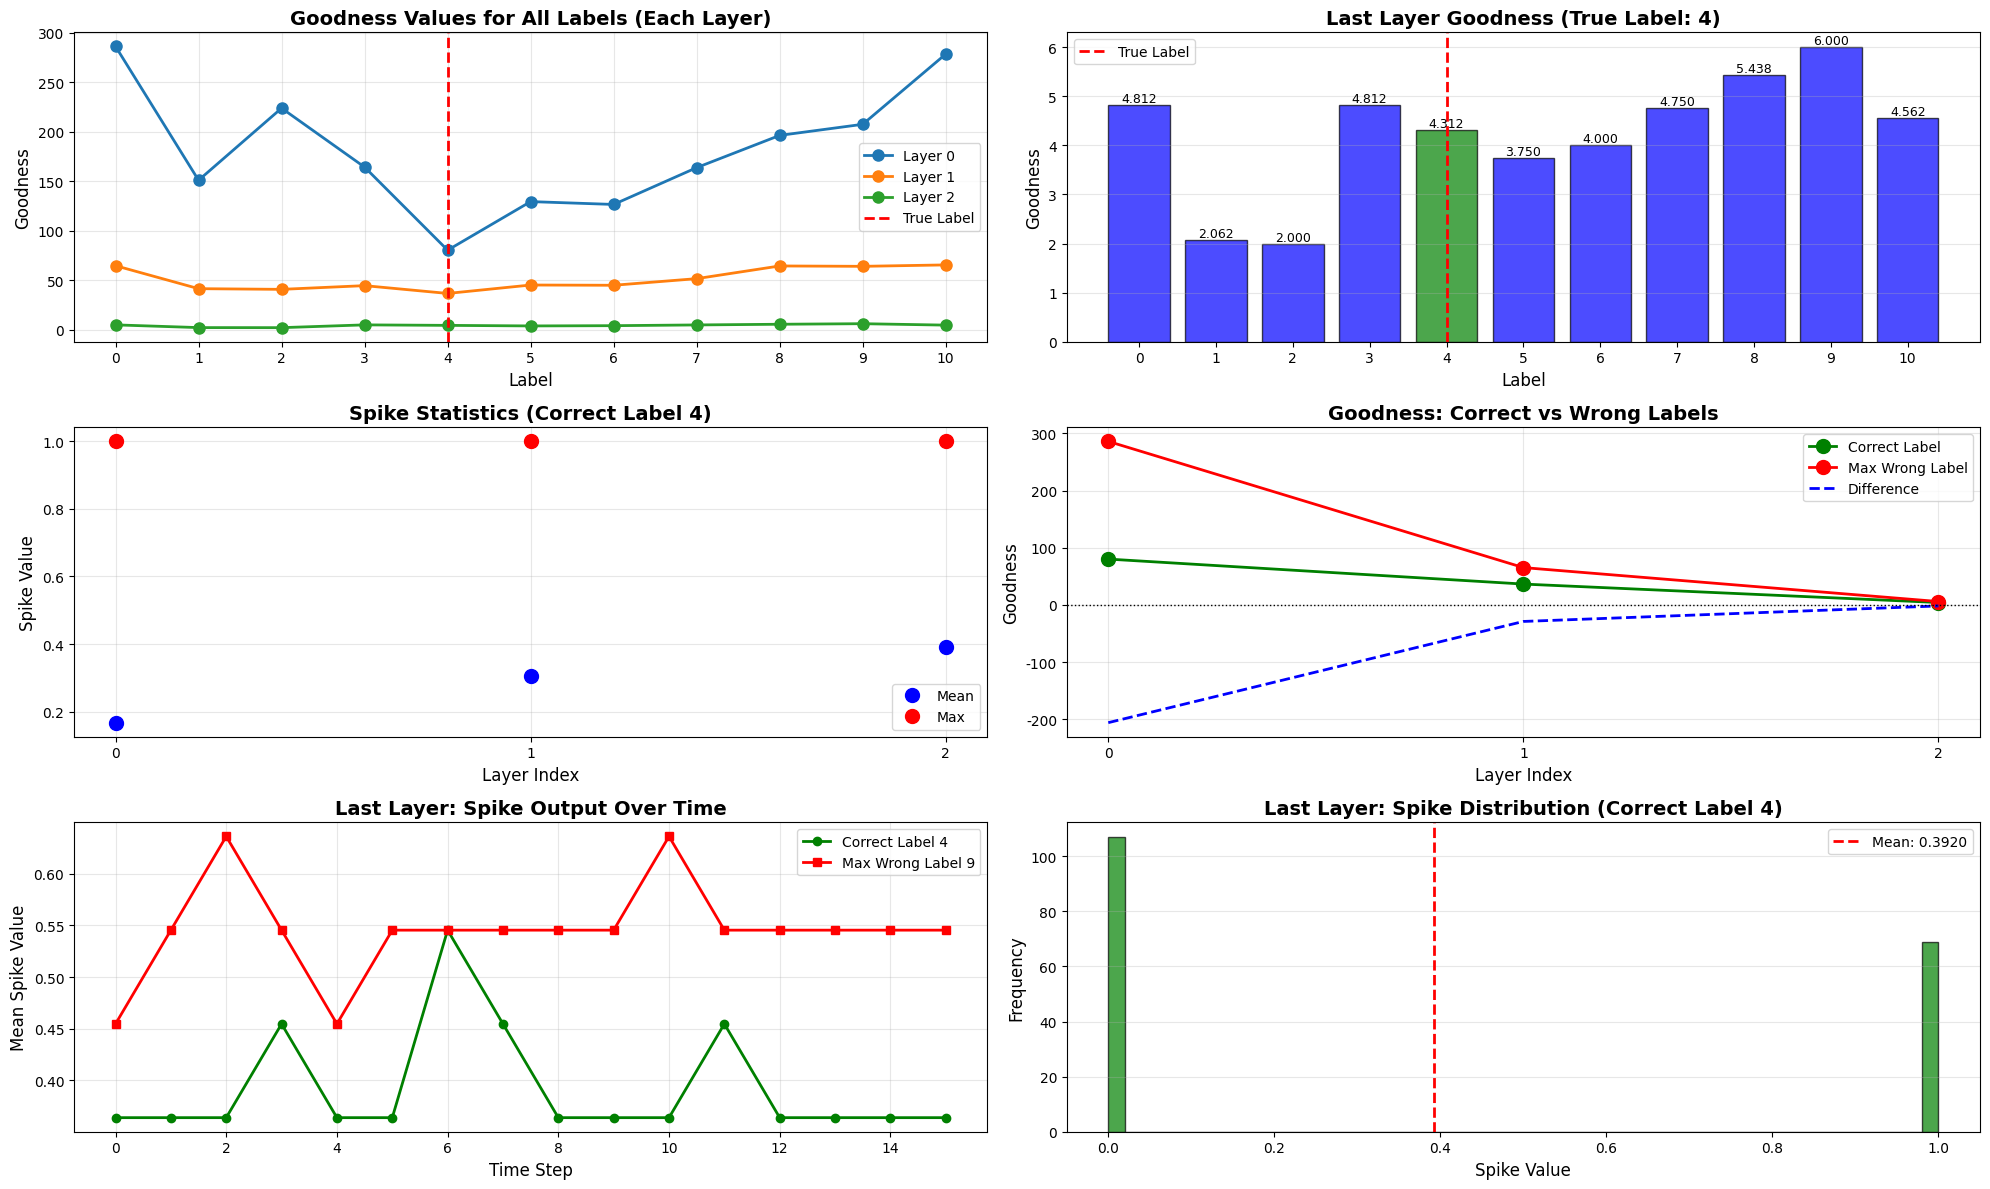


Diagnostic Summary
True Label: 4
Last Layer Prediction: 9
Prediction Correct: False

Last Layer Goodness:
  Correct Label 4: 4.3125
  Max Wrong Label: 8 (6.0000)
  Difference: -1.6875

Goodness Difference Across Layers:
  Layer 0: -205.8125 ✗
  Layer 1: -28.8125 ✗
  Layer 2: -1.6875 ✗

Spike Output Analysis:
  Layer 0:
    Mean: 0.1672, Max: 1.0000, Std: 0.3732
    Activation Rate (spike > 0.1): 0.1672 (16.72%)
  Layer 1:
    Mean: 0.3047, Max: 1.0000, Std: 0.4604
    Activation Rate (spike > 0.1): 0.3047 (30.47%)
  Layer 2:
    Mean: 0.3920, Max: 1.0000, Std: 0.4896
    Activation Rate (spike > 0.1): 0.3920 (39.20%)



: 

In [ ]:
"""
可视化推理过程：观察一个训练样本在各个层的输出
用于诊断准确率低的原因
"""
import matplotlib.pyplot as plt
import numpy as np
import torch

# 设置matplotlib支持中文
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 选择一个训练样本
net.eval()
with torch.no_grad():
    # 获取一个batch的数据
    sample_frame, sample_label = next(iter(train_data_loader))
    sample_frame = sample_frame.to(args.device)
    sample_frame = sample_frame.transpose(0, 1)  # [N, T, C, H, W] -> [T, N, C, H, W]
    sample_label = sample_label.to(args.device)
    
    # 只使用第一个样本
    frame_single = sample_frame[:, 0:1, :, :, :]  # [T, 1, C, H, W]
    label_single = sample_label[0:1]  # [1]
    
    print(f"Sample label: {label_single.item()}")
    print(f"Input frame shape: {frame_single.shape}")
    print(f"\nGoodness Calculation Parameters:")
    print(f"  NORMALIZE_GOODNESS = {NORMALIZE_GOODNESS}")
    print(f"  GOODNESS_USE_SQUARE = {GOODNESS_USE_SQUARE}")
    print(f"  GOODNESS_SCALE_FACTOR = {GOODNESS_SCALE_FACTOR}")
    
    # 为这个样本创建所有可能的label输入（用于测试）
    num_classes = NUM_CLASSES
    T, N, C, H, W = frame_single.shape
    
    # 创建所有label的输入
    all_labels = torch.arange(num_classes, device=label_single.device).unsqueeze(0)  # [1, num_classes]
    all_labels_flat = all_labels.flatten()  # [num_classes]
    
    # 扩展frame以匹配所有label
    frame_expanded = frame_single.expand(-1, num_classes, -1, -1, -1)  # [T, num_classes, C, H, W]
    frame_expanded = frame_expanded.contiguous().view(T, num_classes, C, H, W)  # [T, num_classes, C, H, W]
    
    # 为所有label创建输入
    test_frames_all_labels = create_positive_sample(frame_expanded, all_labels_flat, num_classes=num_classes)
    # test_frames_all_labels shape: [T, num_classes, 811]
    
    # 前向传播，获取所有层的中间输出
    functional.reset_net(net)
    output_all, intermediate_all = net(test_frames_all_labels, return_intermediate=True)
    
    # 获取每一层的输出信息（使用网络内部的属性）
    # 确保使用正确的属性名
    if hasattr(net, 'spiking_neuron_indices'):
        spiking_indices = net.spiking_neuron_indices
    elif hasattr(net, '_spiking_neuron_indices'):
        spiking_indices = net._spiking_neuron_indices
    else:
        raise ValueError("Network does not have spiking_neuron_indices attribute")
    
    num_layers = len(spiking_indices)
    layer_outputs = []
    layer_goodness_values = []
    
    print(f"\n{'='*60}")
    print(f"Layer-wise Output Analysis")
    print(f"{'='*60}")
    
    for layer_idx in range(num_layers):
        spike_output = intermediate_all[layer_idx]  # [T, num_classes, features]
        spiking_idx = spiking_indices[layer_idx]
        
        # 计算每个label的goodness
        goodness_per_label = []
        for label_idx in range(num_classes):
            label_spike_output = spike_output[:, label_idx:label_idx+1, :]  # [T, 1, features]
            goodness = compute_goodness(
                label_spike_output,
                normalize=NORMALIZE_GOODNESS,
                use_square=GOODNESS_USE_SQUARE,
                scale_factor=GOODNESS_SCALE_FACTOR
            )
            goodness_per_label.append(goodness.item())
        
        goodness_per_label = np.array(goodness_per_label)
        layer_goodness_values.append(goodness_per_label)
        layer_outputs.append(spike_output)
        
        # 打印信息
        print(f"\nLayer {layer_idx} (spiking_idx={spiking_idx}):")
        print(f"  Output shape: {spike_output.shape}")
        print(f"  Output min/max: {spike_output.min().item():.4f} / {spike_output.max().item():.4f}")
        print(f"  Output mean: {spike_output.mean().item():.4f}")
        
        # 详细检查正确label的spike输出
        correct_label_idx = label_single.item()
        correct_spike = spike_output[:, correct_label_idx, :]  # [T, features]
        T, features = correct_spike.shape
        spike_mean_time = correct_spike.mean(dim=0)  # [features] - 对时间求平均
        spike_squared_mean_time = (correct_spike ** 2).mean(dim=0)  # [features] - 对时间求平方平均
        
        if layer_idx == 0:  # 只在第一层打印详细计算过程
            print(f"  [Debug] Correct label spike calculation:")
            print(f"    Spike shape: {correct_spike.shape}")
            print(f"    Spike mean over time: {spike_mean_time.mean().item():.4f}")
            print(f"    Spike squared mean over time: {spike_squared_mean_time.mean().item():.4f}")
            if NORMALIZE_GOODNESS:
                expected_goodness = spike_squared_mean_time.sum().item() / features
            else:
                expected_goodness = spike_squared_mean_time.sum().item()
            print(f"    Expected goodness (manual calc): {expected_goodness:.4f}")
            print(f"    Actual goodness: {goodness_per_label[correct_label_idx]:.4f}")
        
        print(f"  Goodness values for all labels:")
        for label_idx in range(num_classes):
            marker = " <-- TRUE" if label_idx == label_single.item() else ""
            print(f"    Label {label_idx}: {goodness_per_label[label_idx]:.4f}{marker}")
        
        # 预测（goodness最高的label）
        pred_label = np.argmax(goodness_per_label)
        is_correct = pred_label == label_single.item()
        print(f"  Predicted label: {pred_label} (correct: {is_correct})")
        max_wrong_goodness = np.max(np.delete(goodness_per_label, label_single.item()))
        goodness_diff = goodness_per_label[label_single.item()] - max_wrong_goodness
        print(f"  Goodness difference (correct - max_wrong): {goodness_diff:.4f}")
        if goodness_diff < 0:
            print(f"  ⚠ WARNING: Correct label has LOWER goodness than wrong label!")
    
    # 可视化
    fig = plt.figure(figsize=(20, 12))
    
    # 1. 各层goodness值对比（所有label）
    ax1 = plt.subplot(3, 2, 1)
    for layer_idx in range(num_layers):
        plt.plot(range(num_classes), layer_goodness_values[layer_idx], 
                marker='o', label=f'Layer {layer_idx}', linewidth=2, markersize=8)
    plt.axvline(x=label_single.item(), color='red', linestyle='--', linewidth=2, label='True Label')
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Goodness', fontsize=12)
    plt.title('Goodness Values for All Labels (Each Layer)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(num_classes))
    
    # 2. 最后一层的goodness值（重点）
    ax2 = plt.subplot(3, 2, 2)
    last_layer_goodness = layer_goodness_values[-1]
    colors = ['green' if i == label_single.item() else 'blue' for i in range(num_classes)]
    bars = plt.bar(range(num_classes), last_layer_goodness, color=colors, alpha=0.7, edgecolor='black')
    plt.axvline(x=label_single.item(), color='red', linestyle='--', linewidth=2, label='True Label')
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Goodness', fontsize=12)
    plt.title(f'Last Layer Goodness (True Label: {label_single.item()})', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(range(num_classes))
    # 添加数值标签
    for i, (bar, val) in enumerate(zip(bars, last_layer_goodness)):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=9)
    
    # 3. 各层spike输出统计（正确label）
    ax3 = plt.subplot(3, 2, 3)
    correct_label = label_single.item()
    layer_spike_stats = []
    for layer_idx in range(num_layers):
        spike_output = layer_outputs[layer_idx]
        correct_spike = spike_output[:, correct_label, :]  # [T, features]
        # 计算spike统计
        spike_mean = correct_spike.mean().item()
        spike_max = correct_spike.max().item()
        spike_sum = correct_spike.sum().item()
        layer_spike_stats.append([spike_mean, spike_max, spike_sum])
        
        # 绘制spike mean和max
        plt.plot(layer_idx, spike_mean, 'bo', markersize=10, label='Mean' if layer_idx == 0 else '')
        plt.plot(layer_idx, spike_max, 'ro', markersize=10, label='Max' if layer_idx == 0 else '')
    
    plt.xlabel('Layer Index', fontsize=12)
    plt.ylabel('Spike Value', fontsize=12)
    plt.title(f'Spike Statistics (Correct Label {correct_label})', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(num_layers))
    
    # 4. 各层goodness差异（正确label vs 其他label）
    ax4 = plt.subplot(3, 2, 4)
    correct_goodness = [layer_goodness_values[layer_idx][correct_label] for layer_idx in range(num_layers)]
    max_wrong_goodness = []
    for layer_idx in range(num_layers):
        wrong_goodness = np.delete(layer_goodness_values[layer_idx], correct_label)
        max_wrong_goodness.append(np.max(wrong_goodness))
    
    goodness_diff = [c - w for c, w in zip(correct_goodness, max_wrong_goodness)]
    plt.plot(range(num_layers), correct_goodness, 'go-', linewidth=2, markersize=10, label='Correct Label')
    plt.plot(range(num_layers), max_wrong_goodness, 'ro-', linewidth=2, markersize=10, label='Max Wrong Label')
    plt.plot(range(num_layers), goodness_diff, 'b--', linewidth=2, markersize=8, label='Difference')
    plt.axhline(y=0, color='black', linestyle=':', linewidth=1)
    plt.xlabel('Layer Index', fontsize=12)
    plt.ylabel('Goodness', fontsize=12)
    plt.title('Goodness: Correct vs Wrong Labels', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(num_layers))
    
    # 5. 最后一层spike输出时间序列（正确label vs 错误label）
    ax5 = plt.subplot(3, 2, 5)
    last_layer_output = layer_outputs[-1]  # [T, num_classes, features]
    correct_spike = last_layer_output[:, correct_label, :]  # [T, features]
    # 计算每个时间步的平均spike
    correct_spike_mean = correct_spike.mean(dim=1).cpu().numpy()  # [T]
    
    # 找到goodness最高的错误label
    wrong_labels = np.delete(np.arange(num_classes), correct_label)
    wrong_goodness = [layer_goodness_values[-1][i] for i in wrong_labels]
    max_wrong_label_idx = wrong_labels[np.argmax(wrong_goodness)]
    max_wrong_spike = last_layer_output[:, max_wrong_label_idx, :]  # [T, features]
    max_wrong_spike_mean = max_wrong_spike.mean(dim=1).cpu().numpy()  # [T]
    
    time_steps = np.arange(len(correct_spike_mean))
    plt.plot(time_steps, correct_spike_mean, 'g-', linewidth=2, label=f'Correct Label {correct_label}', marker='o')
    plt.plot(time_steps, max_wrong_spike_mean, 'r-', linewidth=2, label=f'Max Wrong Label {max_wrong_label_idx}', marker='s')
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Mean Spike Value', fontsize=12)
    plt.title('Last Layer: Spike Output Over Time', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # 6. 最后一层spike输出分布（正确label）
    ax6 = plt.subplot(3, 2, 6)
    correct_spike_flat = correct_spike.flatten().cpu().numpy()
    plt.hist(correct_spike_flat, bins=50, alpha=0.7, color='green', edgecolor='black')
    plt.axvline(x=correct_spike_flat.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {correct_spike_flat.mean():.4f}')
    plt.xlabel('Spike Value', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'Last Layer: Spike Distribution (Correct Label {correct_label})', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # 打印诊断信息
    print(f"\n{'='*60}")
    print(f"Diagnostic Summary")
    print(f"{'='*60}")
    print(f"True Label: {label_single.item()}")
    print(f"Last Layer Prediction: {np.argmax(layer_goodness_values[-1])}")
    print(f"Prediction Correct: {np.argmax(layer_goodness_values[-1]) == label_single.item()}")
    print(f"\nLast Layer Goodness:")
    print(f"  Correct Label {label_single.item()}: {layer_goodness_values[-1][label_single.item()]:.4f}")
    print(f"  Max Wrong Label: {np.argmax(np.delete(layer_goodness_values[-1], label_single.item()))} ({np.max(np.delete(layer_goodness_values[-1], label_single.item())):.4f})")
    print(f"  Difference: {layer_goodness_values[-1][label_single.item()] - np.max(np.delete(layer_goodness_values[-1], label_single.item())):.4f}")
    
    # 检查各层的goodness差异
    print(f"\nGoodness Difference Across Layers:")
    for layer_idx in range(num_layers):
        diff = layer_goodness_values[layer_idx][correct_label] - np.max(np.delete(layer_goodness_values[layer_idx], correct_label))
        status = "✓" if diff > 0 else "✗"
        print(f"  Layer {layer_idx}: {diff:.4f} {status}")
    
    # 检查spike输出是否合理
    print(f"\nSpike Output Analysis:")
    for layer_idx in range(num_layers):
        spike_output = layer_outputs[layer_idx]
        correct_spike = spike_output[:, correct_label, :]
        spike_mean = correct_spike.mean().item()
        spike_max = correct_spike.max().item()
        spike_std = correct_spike.std().item()
        spike_nonzero = (correct_spike > 0.1).float().mean().item()  # 激活率
        
        print(f"  Layer {layer_idx}:")
        print(f"    Mean: {spike_mean:.4f}, Max: {spike_max:.4f}, Std: {spike_std:.4f}")
        print(f"    Activation Rate (spike > 0.1): {spike_nonzero:.4f} ({spike_nonzero*100:.2f}%)")
    
    print(f"\n{'='*60}")



In [ ]:
"""
Check tau parameters of the last layer SRM neuron
Supports both SRMNode and DynamicSRMNode
"""
import torch
import matplotlib.pyplot as plt
import numpy as np
from spikingjelly.activation_based import neuron

# Find all SRM neuron layers in the network
srm_layers = []
for name, module in net.named_modules():
    if isinstance(module, (neuron.SRMNode, neuron.DynamicSRMNode)):
        srm_layers.append((name, module))

print(f"Found {len(srm_layers)} SRM neuron layer(s):")
for i, (name, layer) in enumerate(srm_layers):
    print(f"  {i+1}. {name}")

if len(srm_layers) == 0:
    print("No SRM neurons found in the network!")
else:
    # Get the last layer
    last_layer_name, last_layer = srm_layers[-1]
    print(f"\n{'='*60}")
    print(f"Analyzing the last layer: {last_layer_name}")
    print(f"{'='*60}")
    
    # Extract tau parameters
    if isinstance(last_layer, neuron.DynamicSRMNode):
        # DynamicSRMNode: tau = 1 + exp(-w)
        if last_layer.w_tau_response is not None:
            with torch.no_grad():
                tau_response = 1. + torch.exp(-last_layer.w_tau_response)
                tau_refractory = 1. + torch.exp(-last_layer.w_tau_refractory)
                
                tau_response_np = tau_response.cpu().numpy()
                tau_refractory_np = tau_refractory.cpu().numpy()
                
                print(f"\nType: DynamicSRMNode (learnable parameters)")
                print(f"Number of neurons: {len(tau_response_np)}")
                print(f"\nTau Response Statistics:")
                print(f"  Mean: {tau_response_np.mean():.4f}")
                print(f"  Std: {tau_response_np.std():.4f}")
                print(f"  Min: {tau_response_np.min():.4f}")
                print(f"  Max: {tau_response_np.max():.4f}")
                print(f"  Median: {np.median(tau_response_np):.4f}")
                
                print(f"\nTau Refractory Statistics:")
                print(f"  Mean: {tau_refractory_np.mean():.4f}")
                print(f"  Std: {tau_refractory_np.std():.4f}")
                print(f"  Min: {tau_refractory_np.min():.4f}")
                print(f"  Max: {tau_refractory_np.max():.4f}")
                print(f"  Median: {np.median(tau_refractory_np):.4f}")
                
                # Visualization
                fig, axes = plt.subplots(2, 2, figsize=(14, 10))
                fig.suptitle(f'Tau Parameter Distribution of Last Layer SRM Neuron - {last_layer_name}', fontsize=14, fontweight='bold')
                
                # Tau Response distribution histogram
                axes[0, 0].hist(tau_response_np, bins=30, alpha=0.7, color='blue', edgecolor='black')
                axes[0, 0].set_title('Tau Response Distribution', fontsize=12)
                axes[0, 0].set_xlabel('Tau Response')
                axes[0, 0].set_ylabel('Frequency')
                axes[0, 0].axvline(tau_response_np.mean(), color='red', linestyle='--', linewidth=2, 
                                  label=f'Mean: {tau_response_np.mean():.3f}')
                axes[0, 0].axvline(np.median(tau_response_np), color='green', linestyle='--', linewidth=2, 
                                  label=f'Median: {np.median(tau_response_np):.3f}')
                axes[0, 0].legend()
                axes[0, 0].grid(True, alpha=0.3)
                
                # Tau Refractory distribution histogram
                axes[0, 1].hist(tau_refractory_np, bins=30, alpha=0.7, color='orange', edgecolor='black')
                axes[0, 1].set_title('Tau Refractory Distribution', fontsize=12)
                axes[0, 1].set_xlabel('Tau Refractory')
                axes[0, 1].set_ylabel('Frequency')
                axes[0, 1].axvline(tau_refractory_np.mean(), color='red', linestyle='--', linewidth=2, 
                                  label=f'Mean: {tau_refractory_np.mean():.3f}')
                axes[0, 1].axvline(np.median(tau_refractory_np), color='green', linestyle='--', linewidth=2, 
                                  label=f'Median: {np.median(tau_refractory_np):.3f}')
                axes[0, 1].legend()
                axes[0, 1].grid(True, alpha=0.3)
                
                # Tau Response vs Tau Refractory scatter plot
                axes[1, 0].scatter(tau_response_np, tau_refractory_np, alpha=0.5, s=20, c='purple')
                axes[1, 0].set_title('Tau Response vs Tau Refractory', fontsize=12)
                axes[1, 0].set_xlabel('Tau Response')
                axes[1, 0].set_ylabel('Tau Refractory')
                axes[1, 0].grid(True, alpha=0.3)
                # Add diagonal line
                min_val = min(tau_response_np.min(), tau_refractory_np.min())
                max_val = max(tau_response_np.max(), tau_refractory_np.max())
                axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.3, label='y=x')
                axes[1, 0].legend()
                
                # Neuron index vs Tau values
                neuron_indices = np.arange(len(tau_response_np))
                axes[1, 1].plot(neuron_indices, tau_response_np, 'b-', alpha=0.6, label='Tau Response', linewidth=1.5)
                axes[1, 1].plot(neuron_indices, tau_refractory_np, 'r-', alpha=0.6, label='Tau Refractory', linewidth=1.5)
                axes[1, 1].set_title('Tau Values', fontsize=12)
                axes[1, 1].set_xlabel('Neuron Index')
                axes[1, 1].set_ylabel('Tau Value')
                axes[1, 1].legend()
                axes[1, 1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                # Print tau values for each neuron (show first 10 and last 10 only)
                print(f"\nTau values of first 10 neurons:")
                print("Neuron Index | Tau Response | Tau Refractory")
                print("-" * 45)
                for i in range(min(10, len(tau_response_np))):
                    print(f"  {i:3d}        |  {tau_response_np[i]:8.4f}    |  {tau_refractory_np[i]:8.4f}")
                
                if len(tau_response_np) > 20:
                    print("\n... (middle omitted) ...\n")
                    print(f"Tau values of last 10 neurons:")
                    print("Neuron Index | Tau Response | Tau Refractory")
                    print("-" * 45)
                    for i in range(max(10, len(tau_response_np) - 10), len(tau_response_np)):
                        print(f"  {i:3d}        |  {tau_response_np[i]:8.4f}    |  {tau_refractory_np[i]:8.4f}")
        else:
            print("Tau parameters not initialized! Please run forward pass first.")
            
    elif isinstance(last_layer, neuron.SRMNode):
        # Regular SRMNode: fixed values
        print(f"\nType: SRMNode (fixed parameters)")
        print(f"Tau Response: {last_layer.tau_response}")
        print(f"Tau Refractory: {last_layer.tau_refractory}")
        print(f"Resting potential (v_rest): {last_layer.v_rest}")
        print(f"Threshold (v_threshold): {last_layer.v_threshold}")
    else:
        print(f"Unknown SRM neuron type: {type(last_layer)}")



# visualization

In [ ]:
"""
对比LIF和SRM节点的输出差异
使用相同的输入，对比两个神经元的不同响应
"""
import torch
import matplotlib.pyplot as plt
import numpy as np
from spikingjelly.activation_based import neuron, functional, surrogate

# 设置随机种子以确保可重复性
torch.manual_seed(42)
np.random.seed(42)

# 参数设置
T = 30  # 时间步数
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 创建输入spike序列（模拟event data）
# 生成一个简单的输入模式：在特定时间步产生spike
# 使用较大的输入值以确保能触发神经元
input_spikes = torch.zeros(T, device=device)
input_spikes[5:8] = 2.0   # 第一个burst（输入强度2.0，确保能触发）
input_spikes[15:18] = 4.0  # 第二个burst
input_spikes[25:28] = 8.0  # 第三个burst

print(f"Input spikes shape: {input_spikes.shape}")
print(f"Total input spikes: {input_spikes.sum().item()}")
print(f"Input spike indices: {torch.nonzero(input_spikes).squeeze().tolist()}")
print(f"Input spike values: {input_spikes[input_spikes > 0].cpu().tolist()}")
print(f"Device: {input_spikes.device}")

# 初始化LIF神经元
# 设置较小的tau和较低的threshold，确保能看到输出
lif_neuron = neuron.LIFNode(
    tau=2.0,              # 膜电位时间常数（较小值，响应较快）
    v_threshold=0.5,      # 阈值（降低阈值，更容易触发）
    v_reset=0.0,          # 重置电压
    surrogate_function=surrogate.ATan(),
    detach_reset=False,
    step_mode='m'
).to(device)

# 初始化SRM神经元
# 使用与LIF类似的参数设置，便于对比
srm_neuron = neuron.SRMNode(
    tau_response=2.0,     # EPSP响应时间常数（与LIF的tau类似）
    tau_refractory=2.0,   # 不应期时间常数
    v_rest=0.0,           # 静息电位
    v_threshold=0.5,      # 阈值（与LIF相同）
    v_reset=0.0,          # 重置电压
    surrogate_function=surrogate.ATan(),
    detach_reset=False,
    step_mode='m'
).to(device)

# 重置神经元状态
functional.reset_net(lif_neuron)
functional.reset_net(srm_neuron)

# 准备输入（需要添加batch维度：[T, batch_size, 1]）
input_seq_batch = input_spikes.unsqueeze(1).unsqueeze(2)  # [T, 1, 1]
print(f"\nInput batch shape: {input_seq_batch.shape}")
print(f"Input batch min/max: {input_seq_batch.min().item():.2f} / {input_seq_batch.max().item():.2f}")
print(f"Input batch sample (first 10 time steps): {input_seq_batch[:10, 0, 0].cpu().tolist()}")

# LIF前向传播 - 手动执行charge/fire/reset以便在fire前保存电压
functional.reset_net(lif_neuron)
lif_neuron.train()

lif_outputs_list = []
lif_voltages_list = []

print(f"\n{'='*60}")
print("LIF Neuron Processing (Step-by-Step):")
print(f"{'='*60}")

for t in range(T):
    # 获取当前时间步的输入 [1, 1]
    input_t = input_seq_batch[t].squeeze(0)  # [1, 1]
    
    # 确保v是tensor
    lif_neuron.v_float_to_tensor(input_t)
    
    # 手动执行charge、fire、reset，以便在fire之前保存电压
    lif_neuron.neuronal_charge(input_t)  # 充电
    
    # 在fire之前保存电压（这是我们要显示的电压）
    v_after_charge = lif_neuron.v.clone()
    
    # 执行fire
    spike = lif_neuron.neuronal_fire()
    
    # 执行reset
    lif_neuron.neuronal_reset(spike)
    
    # 保存输出和charge后的电压
    lif_outputs_list.append(spike.squeeze().detach().cpu())
    lif_voltages_list.append(v_after_charge.squeeze().detach().cpu())
    
    # 打印关键时间步的详细信息
    if t < 10 or (5 <= t <= 10) or (15 <= t <= 20) or (25 <= t <= 28):
        input_val = input_t.squeeze().item()
        v_charge_val = v_after_charge.squeeze().item()
        v_after_reset = lif_neuron.v.squeeze().item()
        spike_val = spike.squeeze().item()
        spike_occurred = spike_val > 0.5
        print(f"t={t:2d}: input={input_val:.2f}, v_after_charge={v_charge_val:.4f}, "
              f"v_after_reset={v_after_reset:.4f}, spike={spike_val:.4f} {'[SPIKE!]' if spike_occurred else ''}")

lif_outputs = torch.stack(lif_outputs_list)  # [T]
lif_voltages = torch.stack(lif_voltages_list)  # [T]

print(f"\nLIF output shape: {lif_outputs.shape}")
print(f"LIF output min/max: {lif_outputs.min().item():.4f} / {lif_outputs.max().item():.4f}")
print(f"LIF voltage min/max: {lif_voltages.min().item():.4f} / {lif_voltages.max().item():.4f}")
print(f"LIF spikes (output > 0.5): {(lif_outputs > 0.5).sum().item()}")
print(f"LIF neuron decay_input: {lif_neuron.decay_input}")
print(f"LIF neuron tau: {lif_neuron.tau}")
print(f"LIF neuron v_reset: {lif_neuron.v_reset}")

# 重置SRM状态
functional.reset_net(srm_neuron)
srm_neuron.train()

# SRM前向传播 - 手动执行charge/fire/reset以便在fire前保存电压
srm_outputs_list = []
srm_voltages_list = []

print(f"\n{'='*60}")
print("SRM Neuron Processing (Step-by-Step):")
print(f"{'='*60}")

for t in range(T):
    # 获取当前时间步的输入 [1, 1]
    input_t = input_seq_batch[t].squeeze(0)  # [1, 1]
    
    # 确保v和h是tensor
    srm_neuron.v_float_to_tensor(input_t)
    srm_neuron._h_epsp_float_to_tensor(input_t)
    srm_neuron._h_ref_float_to_tensor(input_t)
    
    # 手动执行charge、fire、reset，以便在fire之前保存电压
    srm_neuron.neuronal_charge(input_t)  # 充电
    
    # 在fire之前保存电压（这是我们要显示的电压）
    v_after_charge = srm_neuron.v.clone()
    h_epsp_val = srm_neuron.h_epsp.clone()
    h_ref_val = srm_neuron.h_ref.clone()
    
    # 执行fire
    spike = srm_neuron.neuronal_fire()
    
    # 执行reset
    srm_neuron.neuronal_reset(spike)
    
    # 保存输出和charge后的电压
    srm_outputs_list.append(spike.squeeze().detach().cpu())
    srm_voltages_list.append(v_after_charge.squeeze().detach().cpu())
    
    # 打印关键时间步的详细信息
    if t < 10 or (5 <= t <= 10) or (15 <= t <= 20) or (25 <= t <= 28):
        input_val = input_t.squeeze().item()
        v_charge_val = v_after_charge.squeeze().item()
        v_after_reset = srm_neuron.v.squeeze().item()
        spike_val = spike.squeeze().item()
        spike_occurred = spike_val > 0.5
        h_epsp_val_item = h_epsp_val.squeeze().item()
        h_ref_val_item = h_ref_val.squeeze().item()
        print(f"t={t:2d}: input={input_val:.2f}, v_after_charge={v_charge_val:.4f}, "
              f"v_after_reset={v_after_reset:.4f}, h_epsp={h_epsp_val_item:.4f}, "
              f"h_ref={h_ref_val_item:.4f}, spike={spike_val:.4f} {'[SPIKE!]' if spike_occurred else ''}")

srm_outputs = torch.stack(srm_outputs_list)  # [T]
srm_voltages = torch.stack(srm_voltages_list)  # [T]

print(f"\nSRM output shape: {srm_outputs.shape}")
print(f"SRM output min/max: {srm_outputs.min().item():.4f} / {srm_outputs.max().item():.4f}")
print(f"SRM voltage min/max: {srm_voltages.min().item():.4f} / {srm_voltages.max().item():.4f}")
print(f"SRM spikes (output > 0.5): {(srm_outputs > 0.5).sum().item()}")

input_spikes_cpu = input_spikes.cpu()

# 可视化 - 使用vlines和scatter组合，更清晰且可控
print("\n" + "="*60)
print("Visualization:")
print("="*60)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('LIF vs SRM Neuron Comparison', fontsize=16, fontweight='bold')

time_steps = np.arange(T)
input_spikes_np = input_spikes_cpu.numpy()

# 子图1：输入spike（使用vlines和scatter组合，更清晰且可控）
ax1 = axes[0]
input_spike_indices = np.where(input_spikes_np > 0)[0]
if len(input_spike_indices) > 0:
    # 使用vlines绘制垂直线
    ax1.vlines(input_spike_indices, 0, input_spikes_np[input_spike_indices], 
               colors='blue', linewidths=2, label='Input Spikes')
    # 使用scatter绘制标记点
    ax1.scatter(input_spike_indices, input_spikes_np[input_spike_indices], 
                c='blue', s=50, marker='o', zorder=3)
    print(f"✓ Found {len(input_spike_indices)} input spikes at indices: {input_spike_indices.tolist()}")
else:
    print("⚠ Warning: No input spikes found!")
    ax1.text(T/2, 1, 'No Input Spikes', ha='center', va='center', fontsize=12, color='red')
ax1.set_ylabel('Input Spike\nMagnitude', fontsize=11)
ax1.set_title('Input Spike Sequence', fontsize=14, fontweight='bold')
ax1.set_xlim(-0.5, T-0.5)
ax1.set_ylim(-0.1, max(2.5, input_spikes_np.max() * 1.2) if len(input_spike_indices) > 0 else 2.5)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 子图2：LIF输出spike
ax2 = axes[1]
lif_outputs_np = lif_outputs.numpy()
lif_spike_times = np.where(lif_outputs_np > 0.5)[0]
if len(lif_spike_times) > 0:
    # 使用vlines绘制垂直线
    ax2.vlines(lif_spike_times, 0, lif_outputs_np[lif_spike_times], 
               colors='red', linewidths=2, label='LIF Output Spikes')
    # 使用scatter绘制标记点
    ax2.scatter(lif_spike_times, lif_outputs_np[lif_spike_times], 
                c='red', s=50, marker='o', zorder=3)
    print(f"✓ LIF fired {len(lif_spike_times)} spikes at: {lif_spike_times.tolist()}")
else:
    ax2.text(T/2, 0.5, 'No LIF Output Spikes', ha='center', va='center', fontsize=12, color='red')
    print("⚠ LIF did not fire any spikes")
ax2.plot(time_steps, lif_outputs_np, 'r--', alpha=0.3, linewidth=1, label='LIF Output (all)')
ax2.set_ylabel('LIF Output\nSpike Value', fontsize=11)
ax2.set_title('LIF Neuron Output', fontsize=14, fontweight='bold')
ax2.set_xlim(-0.5, T-0.5)
ax2.set_ylim(-0.1, max(1.0, lif_outputs_np.max() * 1.2))
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Threshold')

# 子图3：SRM输出spike
ax3 = axes[2]
srm_outputs_np = srm_outputs.numpy()
srm_spike_times = np.where(srm_outputs_np > 0.5)[0]
if len(srm_spike_times) > 0:
    # 使用vlines绘制垂直线
    ax3.vlines(srm_spike_times, 0, srm_outputs_np[srm_spike_times], 
               colors='green', linewidths=2, label='SRM Output Spikes')
    # 使用scatter绘制标记点
    ax3.scatter(srm_spike_times, srm_outputs_np[srm_spike_times], 
                c='green', s=50, marker='s', zorder=3)
    print(f"✓ SRM fired {len(srm_spike_times)} spikes at: {srm_spike_times.tolist()}")
else:
    ax3.text(T/2, 0.5, 'No SRM Output Spikes', ha='center', va='center', fontsize=12, color='red')
    print("⚠ SRM did not fire any spikes")
ax3.plot(time_steps, srm_outputs_np, 'g--', alpha=0.3, linewidth=1, label='SRM Output (all)')
ax3.set_ylabel('SRM Output\nSpike Value', fontsize=11)
ax3.set_title('SRM Neuron Output', fontsize=14, fontweight='bold')
ax3.set_xlim(-0.5, T-0.5)
ax3.set_ylim(-0.1, max(1.0, srm_outputs_np.max() * 1.2))
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Threshold')

# 子图4：膜电位对比
ax4 = axes[3]
ax4.plot(time_steps, lif_voltages.numpy(), 'r-', linewidth=2, label='LIF Voltage', marker='o', markersize=3, alpha=0.8)
ax4.plot(time_steps, srm_voltages.numpy(), 'g-', linewidth=2, label='SRM Voltage', marker='s', markersize=3, alpha=0.8)
ax4.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7, linewidth=2, label='Threshold (0.5)')
ax4.set_xlabel('Time Step', fontsize=12)
ax4.set_ylabel('Membrane Voltage', fontsize=12)
ax4.set_title('Membrane Potential Comparison', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印统计信息
print("\n" + "="*60)
print("Statistics Comparison:")
print("="*60)
print(f"Total input spikes: {input_spikes_cpu.sum().item():.0f}")
print(f"Total LIF output spikes: {(lif_outputs > 0.5).float().sum().item():.0f}")
print(f"Total SRM output spikes: {(srm_outputs > 0.5).float().sum().item():.0f}")
print(f"\nLIF firing rate: {(lif_outputs > 0.5).float().mean().item()*100:.2f}%")
print(f"SRM firing rate: {(srm_outputs > 0.5).float().mean().item()*100:.2f}%")
print(f"\nLIF voltage range: [{lif_voltages.min().item():.3f}, {lif_voltages.max().item():.3f}]")
print(f"SRM voltage range: [{srm_voltages.min().item():.3f}, {srm_voltages.max().item():.3f}]")
print("\nKey Observations:")
print("- LIF: Simple exponential decay of membrane potential")
print("- SRM: Separates input response (EPSP) and refractory response")
print("- SRM explicitly models the refractory period through h_ref")

In [ ]:
"""
SNN反向传播的可视化演示
用最简单的方式展示梯度如何从loss传播到参数
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 第一步：创建一个极简的SNN
# ============================================================================

class SimpleSNN(nn.Module):
    """一个超简单的SNN：只有一个Linear层和一个LIF神经元"""
    def __init__(self):
        super().__init__()
        # 只有一个权重矩阵
        self.weight = nn.Parameter(torch.randn(3, 2))  # 输入2维，输出3维
        print(f"初始权重:\n{self.weight.data}")
    
    def forward(self, x_seq):
        """
        x_seq: [T, N, 2] - 时间步T=3，批次N=1，特征2维
        """
        T, N, _ = x_seq.shape
        
        # 简单的LIF神经元状态
        v = torch.zeros(N, 3)  # 膜电位
        
        spike_seq = []
        for t in range(T):
            # 1. 线性变换
            h = x_seq[t] @ self.weight.T  # [N, 2] @ [2, 3] = [N, 3]
            
            # 2. 积分（简化的LIF，无衰减）
            v = v + h
            
            # 3. 发放脉冲（用sigmoid近似，代替阶跃函数）
            # 真实SNN用surrogate function，这里简化用sigmoid
            spike = torch.sigmoid(v - 1.0)  # 阈值=1.0
            
            spike_seq.append(spike)
        
        # 4. 对时间求平均（发放率编码）
        out_fr = torch.stack(spike_seq).mean(0)  # [N, 3]
        return out_fr

# ============================================================================
# 第二步：创建数据和模型
# ============================================================================

# 创建模型
model = SimpleSNN()

# 创建输入数据：3个时间步，批次大小1，特征2维
x_seq = torch.randn(3, 1, 2, requires_grad=True)
print(f"\n输入数据形状: {x_seq.shape}")
print(f"输入数据:\n{x_seq.data}")

# 真实标签（one-hot编码）
label = torch.tensor([1])  # 类别1
label_onehot = F.one_hot(label, 3).float()
print(f"\n真实标签 (one-hot): {label_onehot}")

# ============================================================================
# 第三步：前向传播
# ============================================================================

print("\n" + "="*60)
print("前向传播过程")
print("="*60)

# 前向传播
out_fr = model(x_seq)
print(f"\n网络输出 (发放率): {out_fr.data}")
print(f"预测类别: {out_fr.argmax(1).item()} (应该是1)")

# ============================================================================
# 第四步：计算损失
# ============================================================================

loss = F.mse_loss(out_fr, label_onehot)
print(f"\n损失值: {loss.item():.4f}")

# ============================================================================
# 第五步：反向传播（关键步骤！）
# ============================================================================

print("\n" + "="*60)
print("反向传播过程")
print("="*60)

# 清零梯度（重要！）
model.zero_grad()

# 反向传播：PyTorch自动计算梯度
loss.backward()

# 查看梯度
print(f"\n权重梯度 ∂loss/∂weight:")
print(model.weight.grad)
print(f"\n输入梯度 ∂loss/∂x_seq:")
print(x_seq.grad)

# ============================================================================
# 第六步：手动验证梯度（理解梯度如何计算的）
# ============================================================================

print("\n" + "="*60)
print("手动验证梯度计算")
print("="*60)

# 手动计算损失对输出的梯度
out_fr_grad = 2 * (out_fr - label_onehot) / out_fr.numel()
print(f"\n1. 损失对输出的梯度 ∂loss/∂out_fr:")
print(out_fr_grad)

# out_fr是时间平均，所以梯度要平均分配
print(f"\n   因为 out_fr = mean(spike_seq)，所以每个时刻的梯度是: {out_fr_grad[0] / 3}")

# ============================================================================
# 第七步：更新参数
# ============================================================================

print("\n" + "="*60)
print("参数更新")
print("="*60)

# 记录更新前的权重
old_weight = model.weight.data.clone()

# 使用简单的SGD更新
learning_rate = 0.1
with torch.no_grad():
    model.weight.data -= learning_rate * model.weight.grad

print(f"\n更新前的权重:\n{old_weight}")
print(f"\n更新后的权重:\n{model.weight.data}")
print(f"\n权重变化:\n{model.weight.data - old_weight}")
print(f"\n注意：权重朝着减少损失的方向调整！")

# ============================================================================
# 第八步：再次前向传播，看损失是否减小
# ============================================================================

print("\n" + "="*60)
print("验证：更新后损失是否减小")
print("="*60)

# 重新前向传播（注意：x_seq需要重新创建，因为之前的requires_grad会保留计算图）
x_seq_new = x_seq.data.clone()
out_fr_new = model(x_seq_new)
loss_new = F.mse_loss(out_fr_new, label_onehot)

print(f"\n更新前的损失: {loss.item():.4f}")
print(f"更新后的损失: {loss_new.item():.4f}")
print(f"损失变化: {loss_new.item() - loss.item():.4f}")

if loss_new.item() < loss.item():
    print("✓ 损失减小了！反向传播和参数更新成功！")
else:
    print("⚠ 注意：由于学习率、网络结构等原因，可能损失暂时增大")

# ============================================================================
# 第九步：展示完整的训练循环（简化版）
# ============================================================================

print("\n" + "="*60)
print("完整的训练循环示例")
print("="*60)

# 创建优化器
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# 模拟几个训练步骤
for step in range(3):
    # 1. 前向传播
    out = model(x_seq.data)
    loss = F.mse_loss(out, label_onehot)
    
    # 2. 反向传播
    optimizer.zero_grad()  # 清零梯度
    loss.backward()        # 计算梯度
    
    # 3. 更新参数
    optimizer.step()       # 更新权重
    
    print(f"Step {step+1}: Loss = {loss.item():.4f}, 预测 = {out.argmax(1).item()}")

print("\n可以看到，随着训练进行，损失逐渐减小！")

# ============================================================================
# 第十步：关键概念总结
# ============================================================================

print("\n" + "="*60)
print("关键概念总结")
print("="*60)

print("""
1. **前向传播**：
   - 数据从输入层 → 隐藏层 → 输出层
   - 每一步都记录在计算图中（PyTorch自动完成）

2. **损失计算**：
   - 对比预测值和真实值
   - 得到标量损失值

3. **反向传播**：
   - 从损失开始，沿着计算图反向传播
   - 使用链式法则计算每个参数的梯度
   - PyTorch的autograd自动完成

4. **参数更新**：
   - 优化器根据梯度更新参数
   - 参数朝着减少损失的方向调整

5. **SNN的特殊性**：
   - 时间展开：需要在时间维度上反向传播（BPTT）
   - 代理梯度：用平滑函数近似不可导的阶跃函数
   - 状态重置：每个batch后重置神经元状态
""")

